# Seeing and Joining Evidence

*thirty-one charts, and merges that do what you meant*

## The question

Two operations that decide whether an analysis is believable and almost never get the care
they deserve: **displaying** evidence, where the wrong chart hides the finding or invents one,
and **combining** it, where a join can explode, evaporate, or quietly reach into the future.
Both are treated the same way here — pick the form deliberately, then check that the result
is what you meant.

## Volatility project join path

Start with the shorter [volatility project data-and-joins notebook](volatility_project_01_data_and_joins.ipynb).
For join depth here, jump directly to [R7.32](#r7-32)–[R7.40](#r7-40): diagnose keys,
constrain cardinality, reconcile row counts, use backward as-of matching and aggregate before
joining. [R7.1](#r7-1)–[R7.31](#r7-31) are an optional visualization reference gallery.

> **Provenance:** stored outputs describe the data and paths printed in that run. Rerun top
> to bottom before treating them as results for the files currently available.

### Evidence you can see

Choosing the *form* is most of the work in a figure; the colours are almost none of it. This
notebook is a gallery of thirty-one charts, each with the situation it is for and the mistake
it prevents. A figure is an argument about evidence, which is why it sits in Part III next to
measurement rather than in a chapter of its own.

The heuristic, in five lines:

* comparing **distributions** — an ECDF beats a histogram past two groups, because histograms
  occlude each other and depend on bin width while ECDFs do neither;
* showing a **relationship** — scatter until the markers overlap, then hexbin;
* showing **change over time** — a line with a rolling band, and a separate drawdown panel
  when the level matters;
* comparing **categories** — a box or a violin, never a bare bar of means, because the spread
  is usually the finding;
* more than about seven series — facet, do not overplot.

Every chart here goes through `rvlab.plotting` so the series reads as one document, and every
one is labelled with units and a title that states the finding rather than the mechanic.

### Combining sources without corrupting them

A join is the operation most likely to silently corrupt an analysis, because all three ways
it fails produce a frame that looks fine:

* **it explodes** — duplicate keys on the right multiply rows, and every subsequent average is
  weighted wrong;
* **it evaporates** — a dtype mismatch matches nothing and returns an empty frame, or worse a
  mostly-empty one;
* **it reaches forward** — an as-of join with the wrong direction matches each row to data
  recorded *after* it, which is a leak that improves your score.

The remedy is the same in all three cases: state what you expect the join to do, then check
it. Diagnose before, constrain during, reconcile after.

Every example records its provenance. Depending on what is available, a stored run may use
project data, a bundled pseudo dataset, or the deterministic fallback fixtures that keep the
recipes executable — including one join that **cannot be done at all**.

In [1]:
try:
    import rvlab
except ModuleNotFoundError:
    import pathlib, sys
    _root = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
                 if (p / "src" / "rvlab").is_dir())
    sys.path.insert(0, str(_root / "src"))
    import rvlab
rvlab.setup_notebook()

roughvol,/Users/xiaohao/rough_pricing_env/Rough-Pricing/src
research_shared,/Users/xiaohao/Effective_Engine/MVP/demo/python/research/shared
● smile_90d,"Multi-maturity: T in [0.019, 0.164]. The term-structure dataset."
● smile_127d,Near-tenor only: T ~ 0.02-0.03. The long-history forecasting dataset.
● smile_5d,Near-tenor only.
● chain_panel,"2025-08-07 to 2025-08-13, one expiry per bar."


## Parameters

In [2]:
PANEL_ENTITIES = 60        # entities in the equity panel used for time-series charts
PANEL_DATES    = 400
SMILE_DATASET  = "smile_5d"
SEED           = 42
PSEUDO_START  = "2024-09-07"
PSEUDO_END    = "2025-09-07"
FRAGMENT_IDS  = 300            # link-table ids given a second, time-ranged mapping
LINK_CUT      = "2025-03-01"

## Where the data comes from

This notebook covers several sections, and each one loads what it needs at its own head — the cell below for the first section, and one like it under every heading after that. They are the only cells that read data: change them and the whole section re-aims at your own frames, with every recipe below unchanged.

In [3]:
import numpy as np, pandas as pd
from rvlab.data import load_panel, load_smile_panel

df = load_smile_panel(SMILE_DATASET)
df["tenor"] = pd.cut(df["T"] * 365, [0, 14, 21, 35, 60],
                     labels=["<14d", "14-21d", "21-35d", "35-60d"]).astype(str)

equity = load_panel(n_entities=PANEL_ENTITIES, n_dates=PANEL_DATES, seed=SEED)
market = equity.groupby("Date")["Close"].mean()
returns = market.pct_change().dropna()

print(f"smile {df.shape} · equity {equity.shape} · {len(returns)} daily returns")
df.head(3)

smile (3810, 10) · equity (24000, 15) · 399 daily returns


,ts,expiry,T,atm_iv,atm_total_var,rr25,bf25,alpha,gamma,tenor
0,2025-08-07 13:35:00+00:00,2025-08-14,0.0192,0.1246,0.0003,-0.0329,0.0032,-0.0542,0.4615,<14d
1,2025-08-07 13:35:00+00:00,2025-08-15,0.0219,0.1278,0.0004,-0.0341,0.0026,-0.0578,0.3394,<14d
2,2025-08-07 13:36:00+00:00,2025-08-14,0.0192,0.1246,0.0003,-0.0332,0.0036,-0.0548,0.5149,<14d


## Recipes in this notebook

**Evidence you can see**

| Recipe | What it does |
|---|---|
| [R7.1](#r7-1) | Histogram with a density overlay |
| [R7.2](#r7-2) | ECDF to compare several distributions |
| [R7.3](#r7-3) | QQ plot to judge the tails |
| [R7.4](#r7-4) | Violin with the observations on top |
| [R7.5](#r7-5) | Ridgeline for many distributions at once |
| [R7.6](#r7-6) | Scatter with a fit and a confidence band |
| [R7.7](#r7-7) | Hexbin when the points overlap |
| [R7.8](#r7-8) | Joint plot with marginals attached |
| [R7.9](#r7-9) | Pair grid for every relationship at once |
| [R7.10](#r7-10) | Pearson against Spearman, and their difference |
| [R7.11](#r7-11) | Clustermap to find redundant feature blocks |
| [R7.12](#r7-12) | Line with a rolling volatility band |
| [R7.13](#r7-13) | Calendar heatmap for periodic effects |
| [R7.14](#r7-14) | ACF and PACF for serial dependence |
| [R7.15](#r7-15) | Cumulative performance with drawdown underneath |
| [R7.16](#r7-16) | Event study around a set of dates |
| [R7.17](#r7-17) | Several series, rebased to a common start |
| [R7.18](#r7-18) | Small multiples instead of overplotting |
| [R7.19](#r7-19) | Bar chart with error bars and value labels |
| [R7.20](#r7-20) | Decile lift — does the ordering actually work? |
| [R7.21](#r7-21) | The residual four-panel |
| [R7.22](#r7-22) | Learning curve — more data, or a bigger model? |
| [R7.23](#r7-23) | Validation curve over one hyperparameter |
| [R7.24](#r7-24) | Calibration curve for a classifier |
| [R7.25](#r7-25) | ROC and precision-recall together |
| [R7.26](#r7-26) | Confusion matrix, normalised by true class |
| [R7.27](#r7-27) | Partial dependence for several features |
| [R7.28](#r7-28) | Check the palette in greyscale |
| [R7.29](#r7-29) | Simulate colour blindness |
| [R7.30](#r7-30) | Annotate the finding |
| [R7.31](#r7-31) | Export at publication quality |

**Combining sources without corrupting them**

| Recipe | What it does |
|---|---|
| [R7.32](#r7-32) | Diagnose a join before you run it |
| [R7.33](#r7-33) | Refuse a join that changes the row count unexpectedly |
| [R7.34](#r7-34) | Find the dtype trap that returns an empty frame |
| [R7.35](#r7-35) | Compare two sources that measure the same thing |
| [R7.36](#r7-36) | Establish that a join is impossible, in sixty seconds |
| [R7.37](#r7-37) | Match each row to the most recent prior observation |
| [R7.38](#r7-38) | Join through a date-ranged link table |
| [R7.39](#r7-39) | Aggregate first, then join |
| [R7.40](#r7-40) | Reconcile row counts across a chain of merges |
| [R7.41](#r7-41) | Melt a frame whose columns are dates |
| [R7.42](#r7-42) | Pivot long back to wide, safely |
| [R7.43](#r7-43) | Stack many files into one frame with a label column |
| [R7.44](#r7-44) | Handle the MultiIndex a groupby hands you |

Each recipe is self-contained: it uses only the names its section's data cell binds, plus the parameters cell and anything it declares under **Needs**. Copy any one of them straight into another project.

## Things to watch

A chart and a join are both claims about the data. Both are easy to make confidently and wrongly.

**Python and pandas**

* **Always `fig, ax = plt.subplots()`.** The implicit pyplot state machine is what makes a
  notebook draw into the previous figure when cells are re-run out of order.
* **Seaborn functions return different things.** Axes-level (`histplot`, `scatterplot`) draw
  into an `ax` you pass; figure-level (`catplot`, `displot`, `FacetGrid`) create their own
  figure and ignore it. Know which you called.
* **A dtype mismatch on the join key returns zero rows, silently.** A tz-aware timestamp and
  the same printed value stored as a string are different keys. Normalise at the loading
  boundary, then inspect overlap: conversion fixes representation, not non-overlapping eras.
* **`merge_asof` requires both sides sorted on the key**, and matches *backwards* by default —
  the wrong `direction` is a look-ahead leak that improves your score.
* **`pivot_table` aggregates duplicates with `mean` and does not tell you.** Use `pivot` when
  you believe the key is unique, so a duplicate raises instead.
* **Annotate with `textcoords="offset points"`**, not by adding to the coordinate — on a
  datetime axis, adding a float to a `Timestamp` raises.

**Analysis**

* **State the expected row count before every join, then check it.** Every recipe here is a
  variation on that one habit. A link table treated as permanent rather than date-ranged
  fans out the input rows; the exact multiplier is printed by the recipe.
* **Say what you found in the title of the figure**, and put an arrow on it. A chart that
  makes the reader locate the finding usually fails to deliver it.
* **Dual axes manufacture correlation.** Two series on their own scales can be made to
  co-move by choosing the limits. Rebase to a common index instead.
* **Past two groups, an ECDF beats a histogram** — histograms occlude each other and depend on
  bin width; ECDFs do neither.
* **Check the figure in greyscale and for colour vision.** The fix is usually a second visual
  channel, not a different palette.


## Evidence you can see

Thirty-one charts, grouped by the question they answer. Each names the situation it is for and the mistake it prevents; the colours are the least of it.

## R7.1 · Histogram with a density overlay
<a id="r7-1"></a>

**Topic** Distributions

**Use when** the first look at one variable. The KDE smooths what the bin width arbitrarily discretises, so plotting both shows you where the binning is misleading you.

**Inputs** `df`, or the arrays named in the call.

**Needs** nothing beyond the setup and data cells

**Gotchas** clip the **display**, never the data. A handful of extreme values otherwise compresses the entire histogram into one bar and you learn nothing.

**See also** [R7.2](#r7-2) (many groups) · [R7.3](#r7-3) (tails)

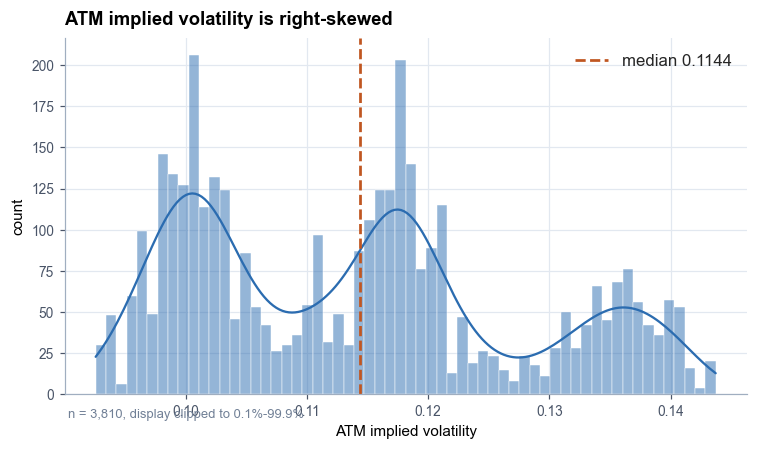

In [4]:
from rvlab.plotting import hist_kde

hist_kde(df["atm_iv"], xlabel="ATM implied volatility",
         title="ATM implied volatility is right-skewed");

## R7.2 · ECDF to compare several distributions
<a id="r7-2"></a>

**Topic** Distributions

**Use when** you have more than two groups. Overlaid histograms occlude one another and change shape with the bin width; ECDFs do neither, and can be read exactly.

**Inputs** `df`, or the arrays named in the call.

**Needs** nothing beyond the setup and data cells

**Gotchas** the maximum **vertical** distance between two curves is the Kolmogorov-Smirnov statistic — so this chart is a visual version of the test in [R6.20](where_the_numbers_come_from.ipynb#r6-20).

**See also** [R7.1](#r7-1) (one variable) · [R7.5](#r7-5) (shape per group)

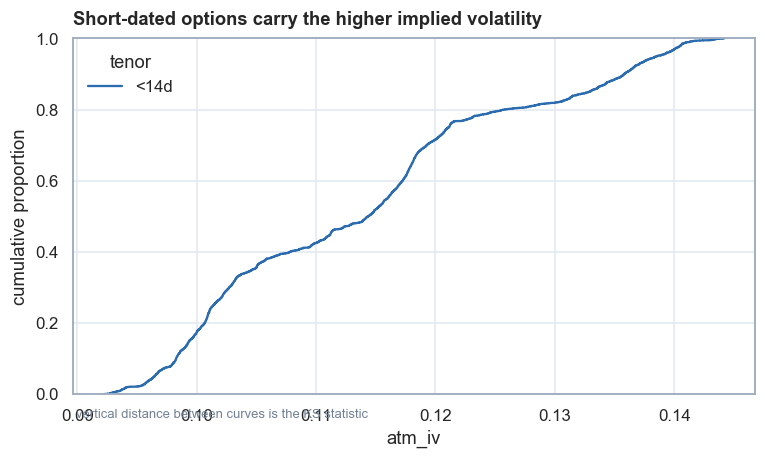

In [5]:
from rvlab.plotting import ecdf_plot

ecdf_plot(df, "atm_iv", group="tenor",
          title="Short-dated options carry the higher implied volatility");

## R7.3 · QQ plot to judge the tails
<a id="r7-3"></a>

**Topic** Distributions

**Use when** you need to know whether a normal assumption is defensible. A histogram spends its resolution on the middle; a QQ plot spends it on the tails, which is where the assumption actually fails.

**Inputs** `df`, or the arrays named in the call.

**Needs** nothing beyond the setup and data cells

**Gotchas** read the shape: an S means heavier tails than the reference, a bend at one end means skew, a straight line means the reference fits. Financial returns essentially never give a straight line.

**See also** [R7.1](#r7-1) (the bulk) · [R7.22](#r7-22) (residual QQ)

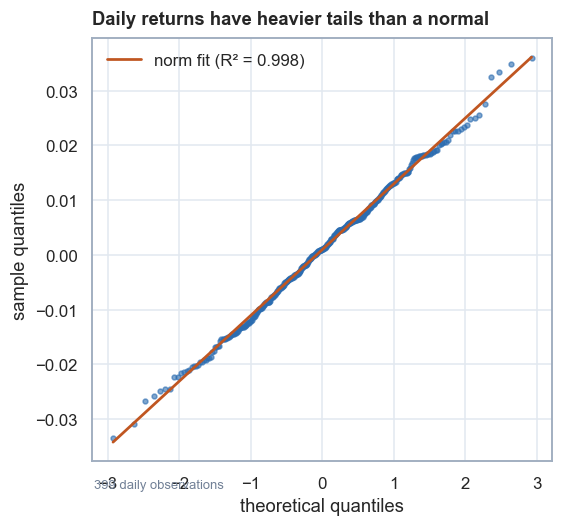

In [6]:
from rvlab.plotting import qq_plot

qq_plot(returns, title="Daily returns have heavier tails than a normal",
        note=f"{len(returns)} daily observations");

## R7.4 · Violin with the observations on top
<a id="r7-4"></a>

**Topic** Distributions

**Use when** comparing distribution *shape* across a handful of groups. The violin shows the shape; the strip shows how many observations produced it.

**Inputs** `df`, or the arrays named in the call.

**Needs** nothing beyond the setup and data cells

**Gotchas** a violin alone will happily imply a smooth bimodal density from nine points. Overlaying the data is what makes it honest.

**See also** [R7.5](#r7-5) (many groups) · [R7.2](#r7-2) (exact comparison)

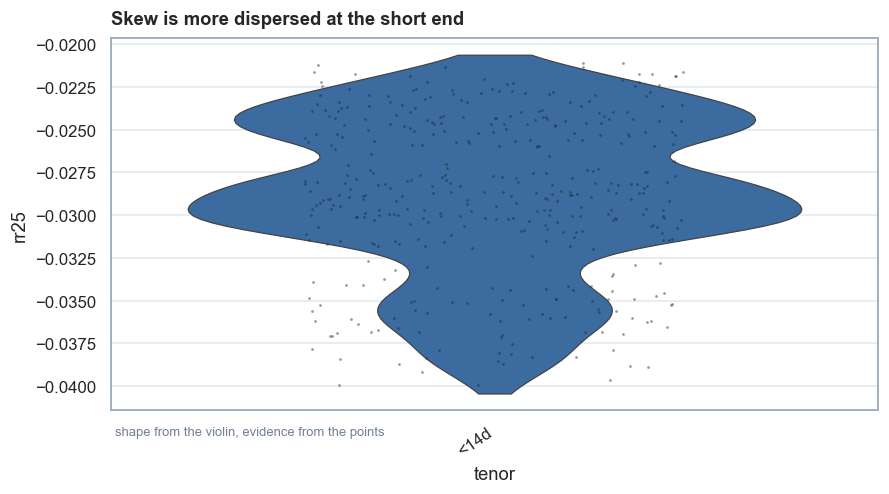

In [7]:
from rvlab.plotting import violin_strip

violin_strip(df, "rr25", "tenor",
             title="Skew is more dispersed at the short end");

## R7.5 · Ridgeline for many distributions at once
<a id="r7-5"></a>

**Topic** Distributions

**Use when** five to fifteen groups whose shapes you want to compare. Stacked densities fit far more groups into one panel than violins do.

**Inputs** `df`, or the arrays named in the call.

**Needs** nothing beyond the setup and data cells

**Gotchas** beyond roughly fifteen groups it becomes unreadable — switch to an ECDF or a facet grid. And the densities are scaled to equal height, so this compares **shape**, not frequency.

**See also** [R7.4](#r7-4) (fewer groups) · [R7.19](#r7-19) (facets)

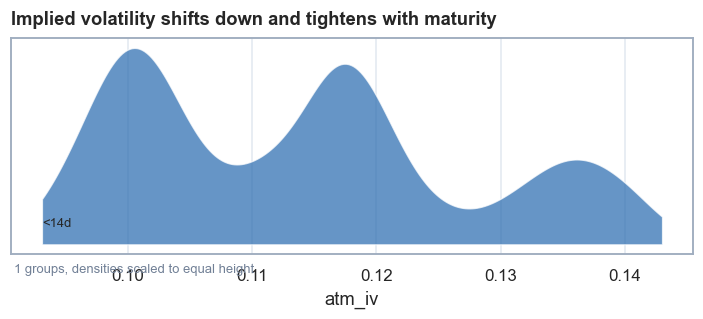

In [8]:
from rvlab.plotting import ridgeline

ridgeline(df, "atm_iv", "tenor",
          title="Implied volatility shifts down and tightens with maturity");

## R7.6 · Scatter with a fit and a confidence band
<a id="r7-6"></a>

**Topic** Relationships

**Use when** showing a bivariate relationship. The band is the part that matters — it distinguishes a real slope from a line drawn through noise.

**Inputs** `df`, or the arrays named in the call.

**Needs** nothing beyond the setup and data cells

**Gotchas** the fit uses every row; only the *display* is subsampled. Rendering 300,000 overlapping markers takes ten seconds and communicates less than 3,000 does.

**See also** [R7.7](#r7-7) (when it overplots) · [R7.10](#r7-10) (linear or not)

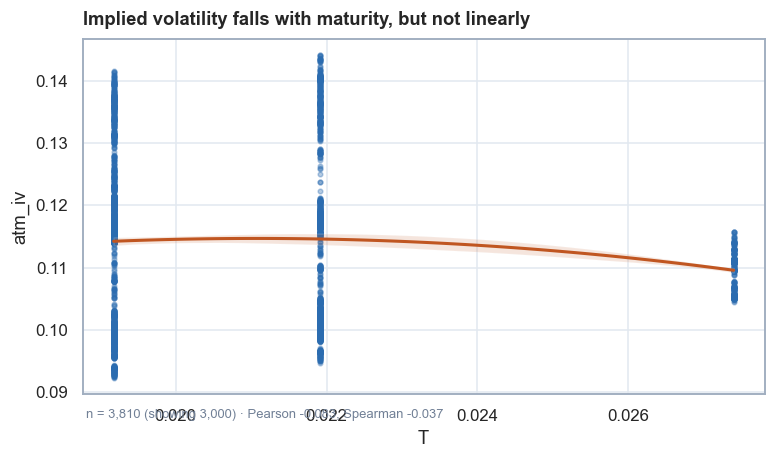

In [9]:
from rvlab.plotting import scatter_fit

scatter_fit(df, "T", "atm_iv",
            title="Implied volatility falls with maturity, but not linearly", order=2);

## R7.7 · Hexbin when the points overlap
<a id="r7-7"></a>

**Topic** Relationships

**Use when** above roughly 5,000 points. A saturated scatter shows you the *outline* of the data and nothing about where the mass sits; hexbin shows the mass.

**Inputs** `df`, or the arrays named in the call.

**Needs** nothing beyond the setup and data cells

**Gotchas** the colour scale is a count, so it is sequential, not diverging. Using a diverging map here invents a meaningless midpoint.

**See also** [R7.6](#r7-6) (fewer points) · [R7.8](#r7-8) (with marginals)

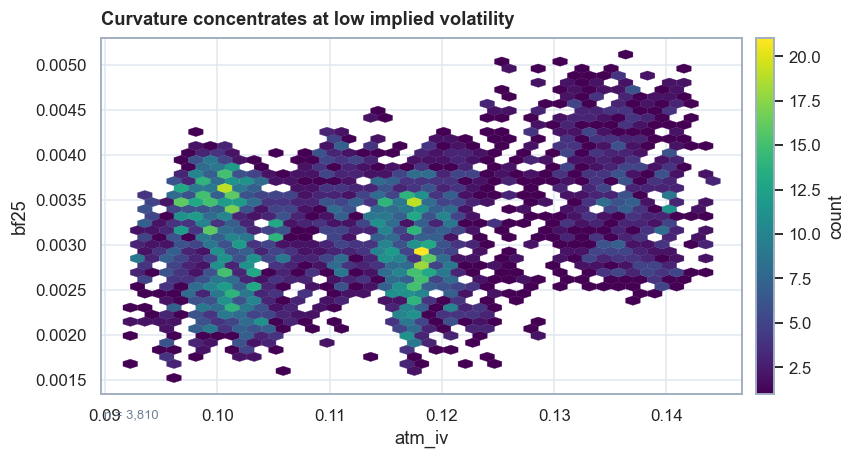

In [10]:
from rvlab.plotting import hexbin_plot

hexbin_plot(df, "atm_iv", "bf25",
            title="Curvature concentrates at low implied volatility");

## R7.8 · Joint plot with marginals attached
<a id="r7-8"></a>

**Topic** Relationships

**Use when** the marginal distributions matter as much as the relationship. Catches the case where a correlation is produced by one clump of a bimodal margin.

**Inputs** `df`, or the arrays named in the call.

**Needs** nothing beyond the setup and data cells

**Gotchas** it is a full figure, not an axes — so it does not compose into a subplot grid. Use it for a standalone look, not as a panel.

**See also** [R7.7](#r7-7) (density only) · [R7.9](#r7-9) (all pairs)

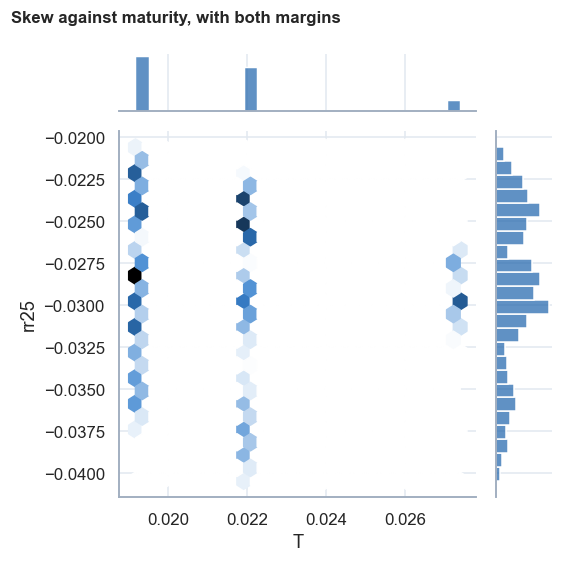

In [11]:
from rvlab.plotting import joint_plot

joint_plot(df, "T", "rr25", kind="hex",
           title="Skew against maturity, with both margins");

## R7.9 · Pair grid for every relationship at once
<a id="r7-9"></a>

**Topic** Relationships

**Use when** the fastest way to see structure in a new feature set — every pairwise scatter and every marginal, in one figure.

**Inputs** `df`, or the arrays named in the call.

**Needs** nothing beyond the setup and data cells

**Gotchas** keep it to four to six columns. The panels shrink and the render cost grows quadratically, and past six the figure is decorative rather than readable.

**See also** [R7.10](#r7-10) (a numeric summary) · [R7.11](#r7-11) (redundancy)

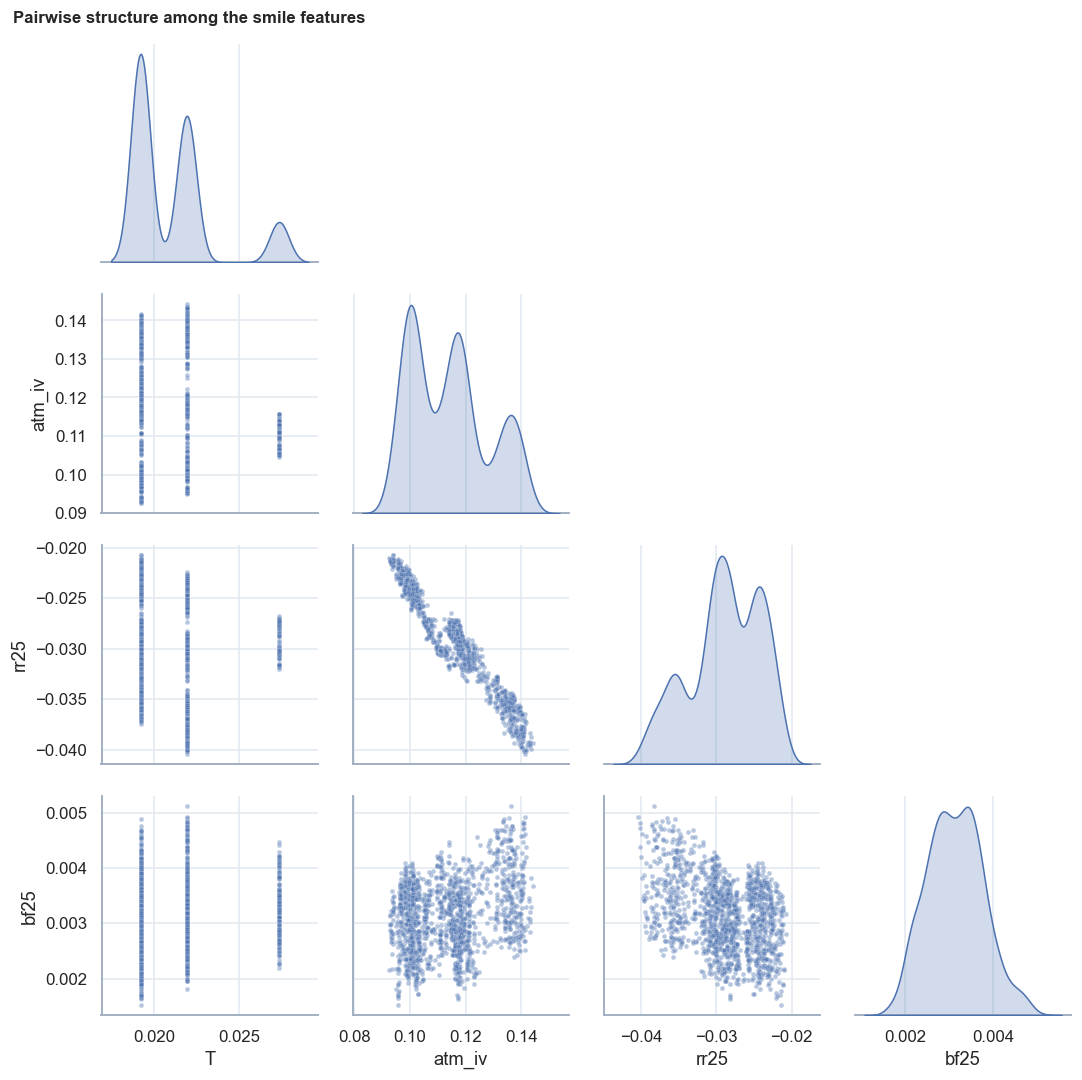

In [12]:
from rvlab.plotting import pair_grid

pair_grid(df, ["T", "atm_iv", "rr25", "bf25"],
          title="Pairwise structure among the smile features");

## R7.10 · Pearson against Spearman, and their difference
<a id="r7-10"></a>

**Topic** Relationships

**Use when** before any linear model. The third panel is the point: where the two disagree, the relationship is monotone but not linear, or a few extreme points are driving Pearson.

**Inputs** `df`, or the arrays named in the call.

**Needs** nothing beyond the setup and data cells

**Gotchas** a large Pearson-minus-Spearman gap is a warning that a linear model is being told something misleading — either transform the feature or use a model that does not assume linearity.

**See also** [R7.11](#r7-11) (clustered) · [R1.22](the_volatility_surface.ipynb#r1-22) (which to use)

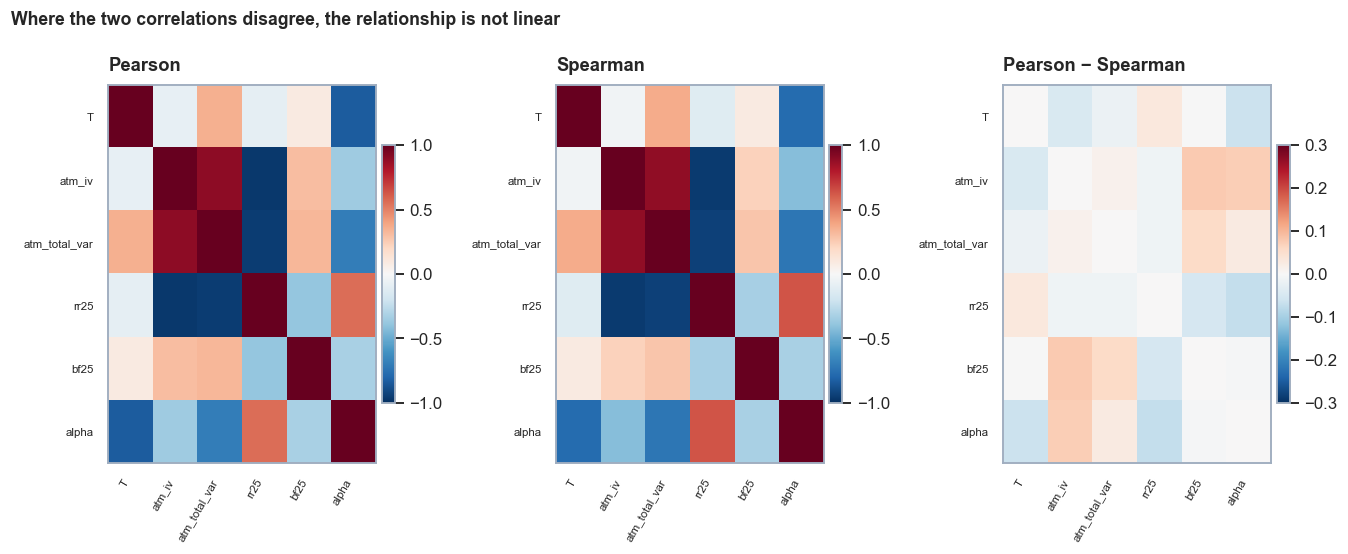

In [13]:
from rvlab.plotting import correlation_contrast

correlation_contrast(df[["T", "atm_iv", "atm_total_var", "rr25", "bf25", "alpha"]]);

## R7.11 · Clustermap to find redundant feature blocks
<a id="r7-11"></a>

**Topic** Relationships

**Use when** deciding what to drop. Reordering the correlation matrix by similarity groups features that move together, which a fixed-order heatmap cannot show.

**Inputs** `df`, or the arrays named in the call.

**Needs** nothing beyond the setup and data cells

**Gotchas** the dendrogram is doing hierarchical clustering on correlation distance — it is a *suggestion* about structure, not a partition. Do not read the cluster count as meaningful.

**See also** [R7.10](#r7-10) (raw correlations) · [R4.4](when_a_result_is_real.ipynb#r4-4) (PCA)

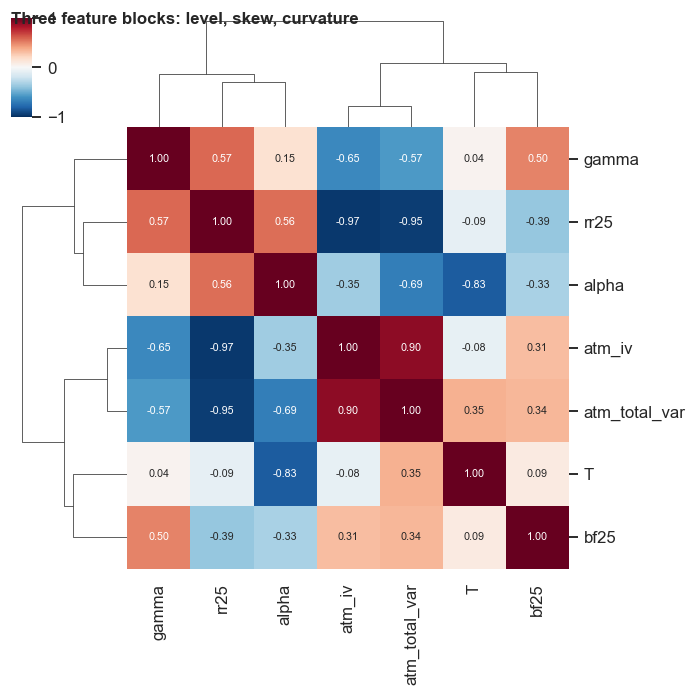

In [14]:
from rvlab.plotting import cluster_map

cluster_map(df[["T", "atm_iv", "atm_total_var", "rr25", "bf25", "alpha", "gamma"]],
            title="Three feature blocks: level, skew, curvature");

## R7.12 · Line with a rolling volatility band
<a id="r7-12"></a>

**Topic** Time series

**Use when** any level that moves. The band makes the line interpretable: a move of 0.02 means something different when the recent standard deviation is 0.005 than when it is 0.05.

**Inputs** `df`, or the arrays named in the call.

**Needs** nothing beyond the setup and data cells

**Gotchas** the band is backward-looking by construction, so the first `window` observations are missing — do not read the left edge as a narrowing of volatility.

**See also** [R7.13](#r7-13) (seasonality) · [R7.15](#r7-15) (drawdown)

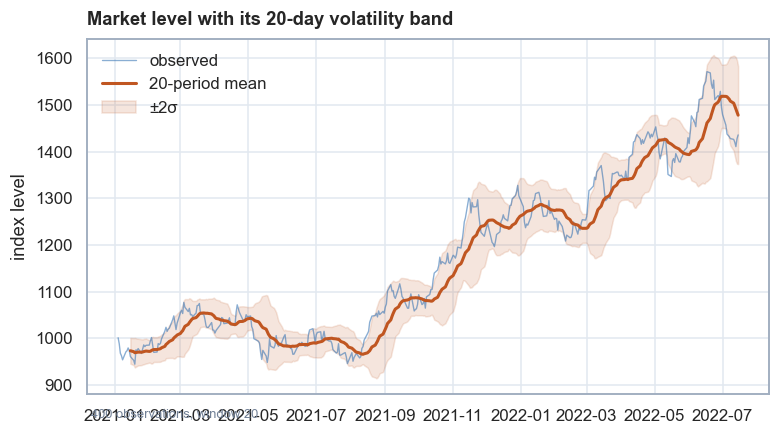

In [15]:
from rvlab.plotting import rolling_band

rolling_band(market, window=20, ylabel="index level",
             title="Market level with its 20-day volatility band");

## R7.13 · Calendar heatmap for periodic effects
<a id="r7-13"></a>

**Topic** Time series

**Use when** you suspect a day-of-week or turn-of-month effect. These are periodic at a scale a line chart compresses away entirely.

**Inputs** `df`, or the arrays named in the call.

**Needs** nothing beyond the setup and data cells

**Gotchas** use a diverging colour map centred at zero for returns — the sign is the finding, and a sequential map hides where the data crosses zero.

**See also** [R7.12](#r7-12) (the level) · [R7.14](#r7-14) (serial dependence)

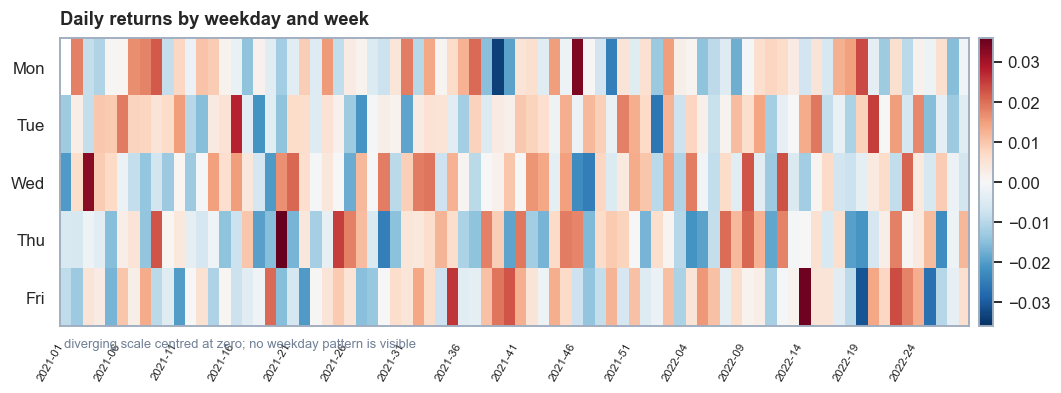

In [16]:
from rvlab.plotting import calendar_heatmap

calendar_heatmap(returns, title="Daily returns by weekday and week",
                 note="diverging scale centred at zero; no weekday pattern is visible");

## R7.14 · ACF and PACF for serial dependence
<a id="r7-14"></a>

**Topic** Time series

**Use when** before modelling a time series, and again on the residuals afterwards. ACF shows total dependence at each lag; PACF shows what is left after the shorter lags are removed.

**Inputs** `df`, or the arrays named in the call.

**Needs** nothing beyond the setup and data cells

**Gotchas** the shaded band is the 95% white-noise interval. Bars inside it are noise; the *first* bar outside it on the residuals of a fitted model means the standard errors that model reported are wrong.

**See also** [R7.22](#r7-22) (residuals in order) · [R3.18](forecasting_the_smile.ipynb#r3-18) (HAC tests)

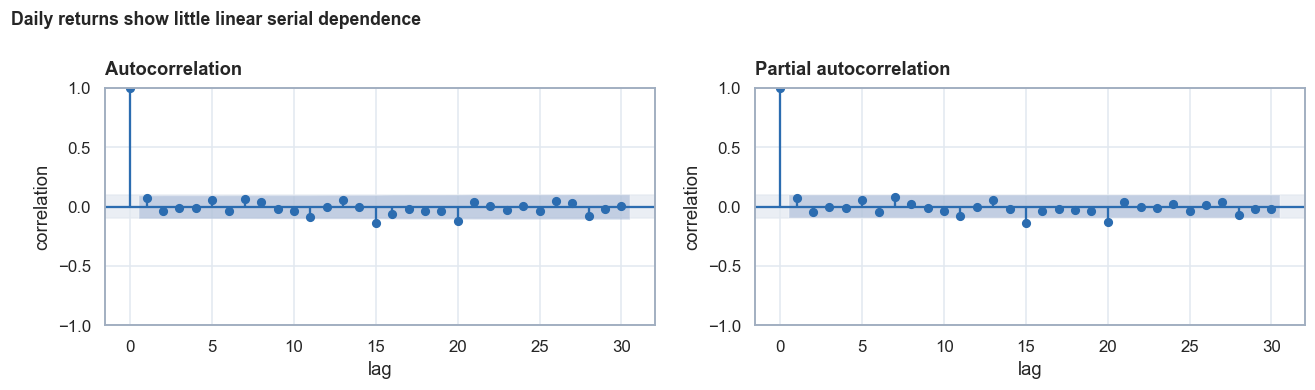

In [17]:
from rvlab.plotting import acf_pacf

acf_pacf(returns, lags=30,
         title="Daily returns show little linear serial dependence");

## R7.15 · Cumulative performance with drawdown underneath
<a id="r7-15"></a>

**Topic** Time series

**Use when** evaluating anything cumulative. A Sharpe ratio says nothing about the path; the underwater panel answers the question that decides whether a strategy is runnable.

**Inputs** `df`, or the arrays named in the call.

**Needs** nothing beyond the setup and data cells

**Gotchas** cumulative **sum** for a metric-scale spread return, cumulative **product** for an actual portfolio. Compounding a quantity that is not reinvested implies a story the data does not support.

**See also** [R7.12](#r7-12) (levels) · [R8.17](measuring_and_trading_volatility.ipynb#r8-17) (the full tearsheet)

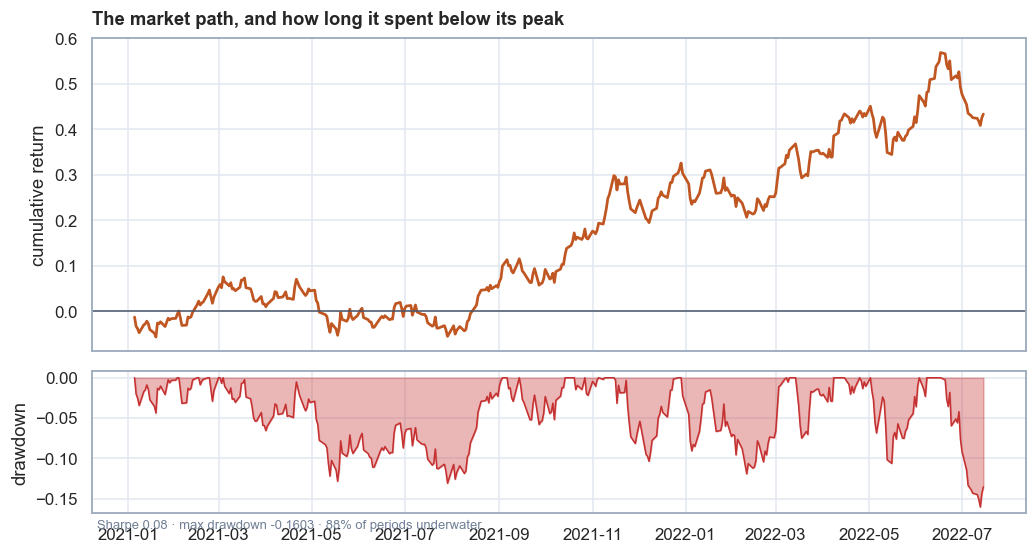

In [18]:
from rvlab.plotting import drawdown_underwater

drawdown_underwater(returns, compound=True,
                    title="The market path, and how long it spent below its peak");

## R7.16 · Event study around a set of dates
<a id="r7-16"></a>

**Topic** Time series

**Use when** you want the average behaviour around events — earnings, shocks, regime changes. Align every event at t=0, re-base, and average.

**Inputs** `df`, or the arrays named in the call.

**Needs** nothing beyond the setup and data cells

**Gotchas** the confidence band is essential and usually omitted. Without it an event study will show you a compelling pattern in three observations.

**See also** [R7.13](#r7-13) (periodic effects) · [R4.12](when_a_result_is_real.ipynb#r4-12) (regime conditioning)

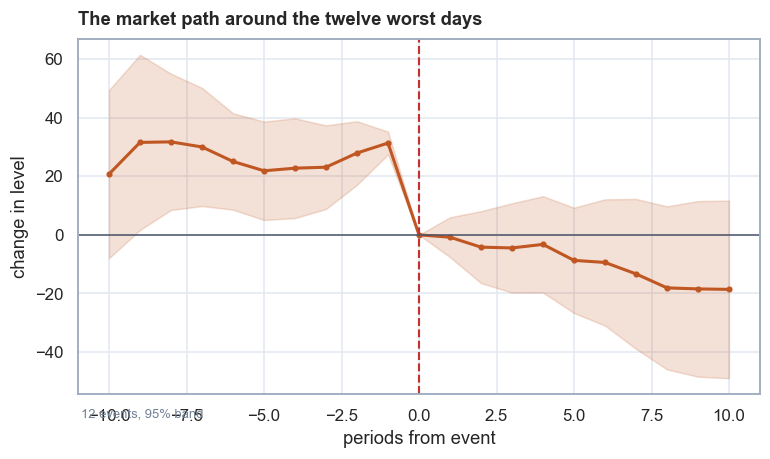

In [19]:
from rvlab.plotting import event_study

shocks = returns.nsmallest(12).index
frame = market.rename("level").reset_index()
event_study(frame, "level", "Date", shocks, window=10,
            title="The market path around the twelve worst days");

## R7.17 · Several series, rebased to a common start
<a id="r7-17"></a>

**Topic** Time series

**Use when** comparing series with different scales. Rebasing to 1.0 makes them comparable on one axis.

**Inputs** `df`, or the arrays named in the call.

**Needs** nothing beyond the setup and data cells

**Gotchas** **never use a twin y-axis for this.** Two axes with independently chosen ranges can be slid until any two series appear to move together; the reader has no way to tell. Rebasing is honest, a second axis is not.

**See also** [R7.12](#r7-12) (one series) · [R7.19](#r7-19) (many series)

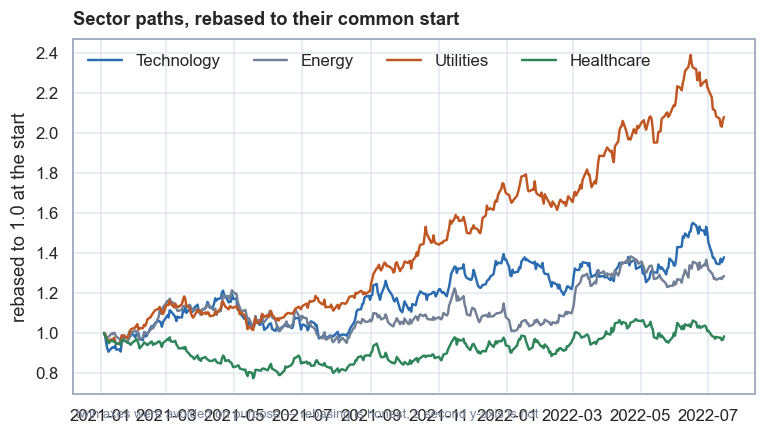

In [20]:
from rvlab.plotting import multi_series

wide = equity.pivot_table(index="Date", columns="Sector", values="Close", aggfunc="mean")
multi_series(wide, ["Technology", "Energy", "Utilities", "Healthcare"],
             title="Sector paths, rebased to their common start");

## R7.18 · Small multiples instead of overplotting
<a id="r7-18"></a>

**Topic** Categorical

**Use when** more than about seven groups. Faceting keeps every group readable and makes differences in *shape* obvious, which an overplotted single panel destroys.

**Inputs** `df`, or the arrays named in the call.

**Needs** nothing beyond the setup and data cells

**Gotchas** share the axes across panels, or the reader will compare shapes that are drawn at different scales and conclude the opposite of the truth.

**See also** [R7.5](#r7-5) (stacked densities) · [R7.17](#r7-17) (one panel)

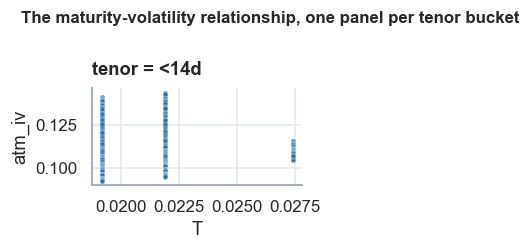

In [21]:
from rvlab.plotting import facet_grid

facet_grid(df, "T", "atm_iv", "tenor", col_wrap=4,
           title="The maturity-volatility relationship, one panel per tenor bucket");

## R7.19 · Bar chart with error bars and value labels
<a id="r7-19"></a>

**Topic** Categorical

**Use when** comparing a handful of measured quantities. If you have the uncertainty, plot it.

**Inputs** `df`, or the arrays named in the call.

**Needs** nothing beyond the setup and data cells

**Gotchas** a bar of means with no error bar is the least informative chart in common use: it asserts a difference without showing whether one exists. Two bars whose error bars overlap heavily are not different.

**See also** [R7.20](#r7-20) (ordering quality) · [R5.24](the_cross_section.ipynb#r5-24) (model comparison)

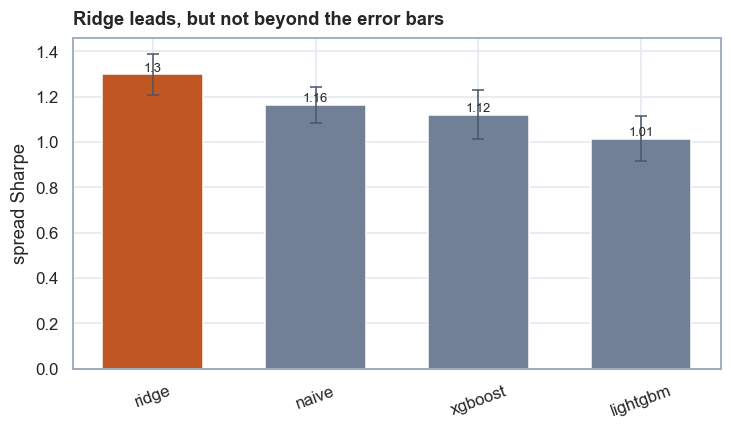

In [22]:
from rvlab.plotting import annotated_bar

scores = pd.Series({"ridge": 1.298, "xgboost": 1.121, "lightgbm": 1.014, "naive": 1.163})
errors = pd.Series({"ridge": 0.09, "xgboost": 0.11, "lightgbm": 0.10, "naive": 0.08})
annotated_bar(scores, errors, ylabel="spread Sharpe",
              title="Ridge leads, but not beyond the error bars");

## R7.20 · Decile lift — does the ordering actually work?
<a id="r7-20"></a>

**Topic** Model evaluation

**Use when** the most direct answer to 'is this model useful'. Bin by predicted score and plot the mean outcome per bin.

**Inputs** `df`, or the arrays named in the call.

**Needs** nothing beyond the setup and data cells

**Gotchas** a monotone staircase means the ranking is real. A flat or ragged one means the aggregate metric is being carried by something other than a usable ordering — which is exactly the case where a good AUC misleads you.

**See also** [R7.25](#r7-25) (calibration) · [R5.18](the_cross_section.ipynb#r5-18) (ranking metrics)

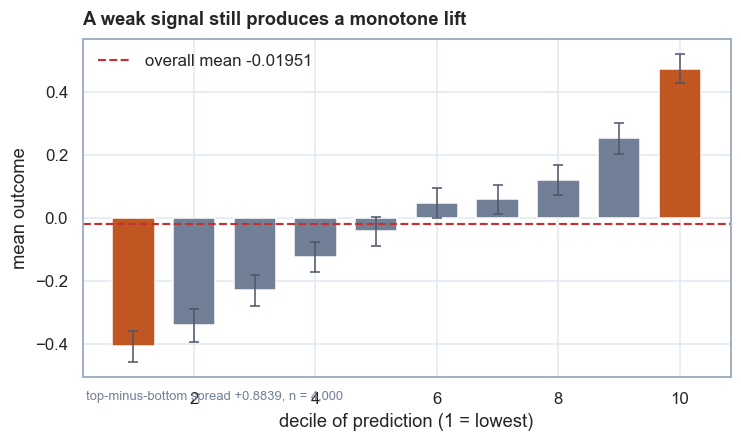

In [23]:
from rvlab.plotting import decile_lift

rng = np.random.default_rng(SEED)
truth = rng.normal(size=4000)
signal = truth * 0.25 + rng.normal(size=4000)      # a weak but real signal
decile_lift(truth, signal, ylabel="mean outcome",
            title="A weak signal still produces a monotone lift");

## R7.21 · The residual four-panel
<a id="r7-21"></a>

**Topic** Model diagnostics

**Use when** after every regression fit. Four panels, four assumptions: linearity, normality, homoskedasticity, and independence.

**Inputs** `df`, or the arrays named in the call.

**Needs** nothing beyond the setup and data cells

**Gotchas** the fourth panel — residuals in observation order — is the one usually omitted and usually informative on time-series data. Serial correlation there invalidates every standard error the model reported.

**See also** [R7.3](#r7-3) (QQ alone) · [R7.14](#r7-14) (ACF of residuals)

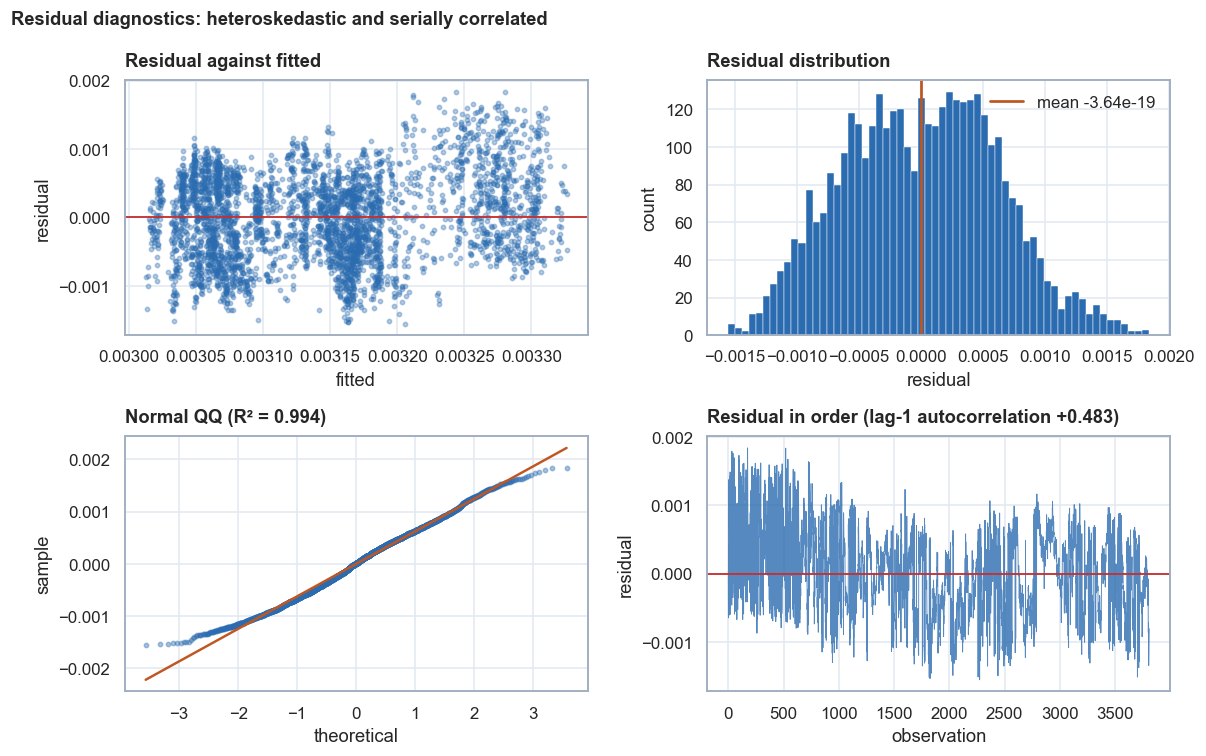

In [24]:
from sklearn.linear_model import Ridge
from rvlab.plotting import residual_panel

X = df[["T", "atm_iv", "atm_total_var"]].to_numpy()
y = df["bf25"].to_numpy()
residual_panel(y, Ridge().fit(X, y).predict(X),
               title="Residual diagnostics: heteroskedastic and serially correlated");

## R7.22 · Learning curve — more data, or a bigger model?
<a id="r7-22"></a>

**Topic** Model diagnostics

**Use when** the model underperforms and you must decide what to change. The shape of the two curves gives the diagnosis directly.

**Inputs** `df`, or the arrays named in the call.

**Needs** R7.21 — run those first. This recipe builds on what they define.

**Gotchas** curves converging together at a low score mean **bias** — a bigger model, not more data. A wide persistent gap means **variance** — more data or more regularisation. Still separating at the right edge means more data would genuinely help.

**See also** [R7.23](#r7-23) (one hyperparameter) · [R8.26](measuring_and_trading_volatility.ipynb#r8-26) (nested CV)

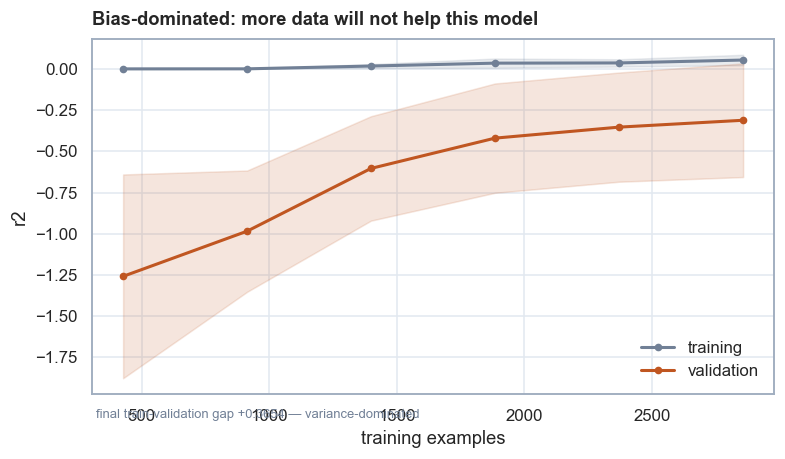

In [25]:
from sklearn.linear_model import Ridge
from rvlab.plotting import learning_curve_plot

learning_curve_plot(Ridge(alpha=1.0), X, y, cv=4, scoring="r2",
                    title="Bias-dominated: more data will not help this model");

## R7.23 · Validation curve over one hyperparameter
<a id="r7-23"></a>

**Topic** Model diagnostics

**Use when** you are about to tune something and want to know whether it matters at all.

**Inputs** `df`, or the arrays named in the call.

**Needs** R7.21 — run those first. This recipe builds on what they define.

**Gotchas** a flat curve means the parameter is irrelevant and the tuning was theatre. A sharp peak means the choice is real — and should be made inside cross-validation, not by reading this plot, which was drawn on the same data.

**See also** [R7.22](#r7-22) (data size) · [R3.13](forecasting_the_smile.ipynb#r3-13) (grid search)

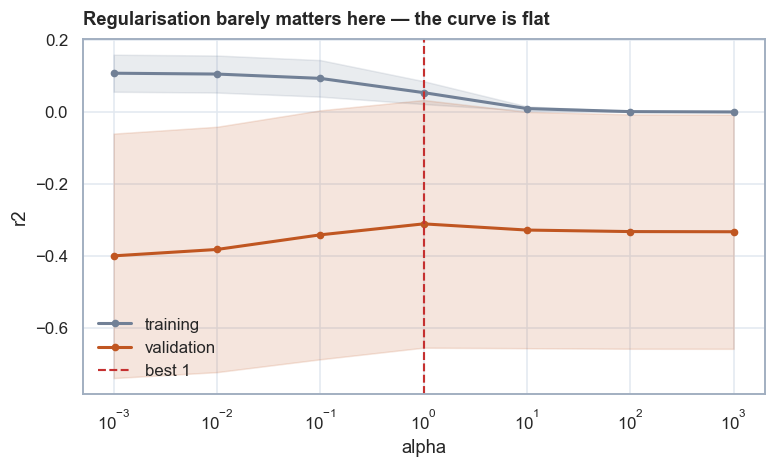

In [26]:
from sklearn.linear_model import Ridge
from rvlab.plotting import validation_curve_plot

validation_curve_plot(Ridge(), X, y, "alpha", [1e-3, 1e-2, 1e-1, 1, 10, 100, 1000],
                      cv=4, scoring="r2",
                      title="Regularisation barely matters here — the curve is flat");

## R7.24 · Calibration curve for a classifier
<a id="r7-24"></a>

**Topic** Model diagnostics

**Use when** you will act on the predicted *probability* rather than the ordering — position sizing, expected value, a threshold with a cost attached.

**Inputs** `df`, or the arrays named in the call.

**Needs** nothing beyond the setup and data cells

**Gotchas** a model can rank perfectly and be badly calibrated: excellent ROC-AUC, probabilities systematically too confident. AUC cannot detect this and the Brier score can.

**See also** [R7.25](#r7-25) (ranking quality) · [R8.22](measuring_and_trading_volatility.ipynb#r8-22) (fixing calibration)

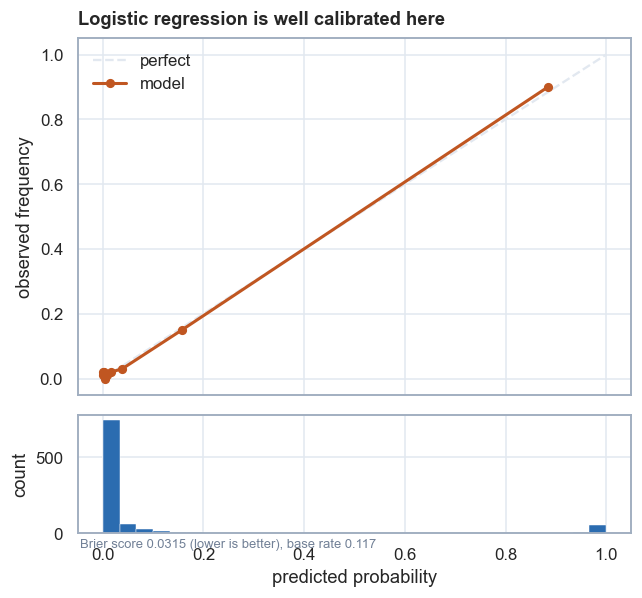

In [27]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from rvlab.plotting import calibration_plot

Xc, yc = make_classification(4000, 12, weights=[0.88], random_state=SEED)
Xtr, Xte, ytr, yte = train_test_split(Xc, yc, random_state=SEED)
proba = LogisticRegression(max_iter=1000).fit(Xtr, ytr).predict_proba(Xte)[:, 1]
calibration_plot(yte, proba, title="Logistic regression is well calibrated here");

## R7.25 · ROC and precision-recall together
<a id="r7-25"></a>

**Topic** Model diagnostics

**Use when** any classification result. Always both, never ROC alone.

**Inputs** `df`, or the arrays named in the call.

**Needs** R7.24 — run those first. This recipe builds on what they define.

**Gotchas** **ROC-AUC is nearly insensitive to class imbalance**, which sounds like a virtue and is not: on a 12%-positive problem the curve is dominated by abundant negatives, and a model can score 0.9 while being useless in production. Average precision, whose baseline is the positive rate, tells the truth.

**See also** [R7.24](#r7-24) (calibration) · [R3.20](forecasting_the_smile.ipynb#r3-20) (metric choice)

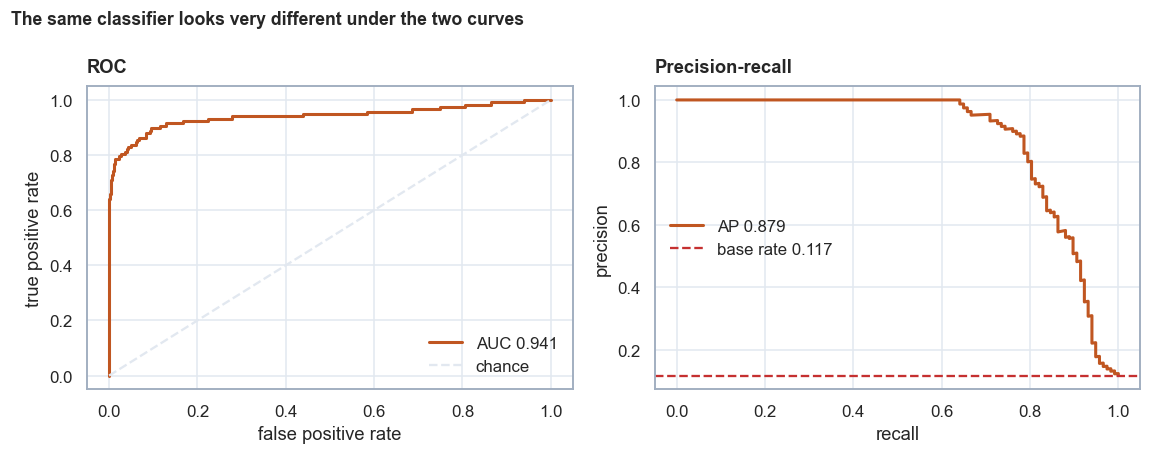

In [28]:
from rvlab.plotting import roc_pr_plot

roc_pr_plot(yte, proba,
            title="The same classifier looks very different under the two curves");

## R7.26 · Confusion matrix, normalised by true class
<a id="r7-26"></a>

**Topic** Model diagnostics

**Use when** reporting a classification result to someone who will act on it. Row-normalising turns each row into per-class recall.

**Inputs** `df`, or the arrays named in the call.

**Needs** R7.24 — run those first. This recipe builds on what they define.

**Gotchas** a raw count matrix on imbalanced data is dominated by the majority class and tells you almost nothing. Normalise, and say which way you normalised.

**See also** [R7.25](#r7-25) (threshold-free) · [R8.23](measuring_and_trading_volatility.ipynb#r8-23) (choosing the threshold)

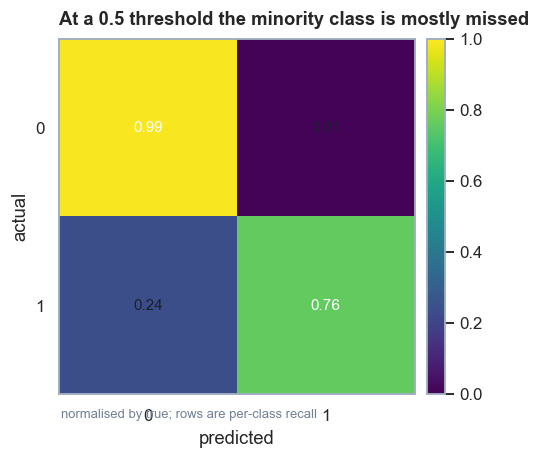

In [29]:
from rvlab.plotting import confusion_matrix_plot

confusion_matrix_plot(yte, (proba >= 0.5).astype(int),
                      title="At a 0.5 threshold the minority class is mostly missed");

## R7.27 · Partial dependence for several features
<a id="r7-27"></a>

**Topic** Model diagnostics

**Use when** you have importance rankings and want the *shape* of each effect, not just its size.

**Inputs** `df`, or the arrays named in the call.

**Needs** R7.21 — run those first. This recipe builds on what they define.

**Gotchas** > ⚠️ **Extrapolation:** partial dependence evaluates the model at feature combinations that may never occur. Where features are correlated, the tails of these curves are model artefacts rather than findings.

**See also** [R4.4](when_a_result_is_real.ipynb#r4-4) (the same tool) · [R7.21](#r7-21) (residuals)

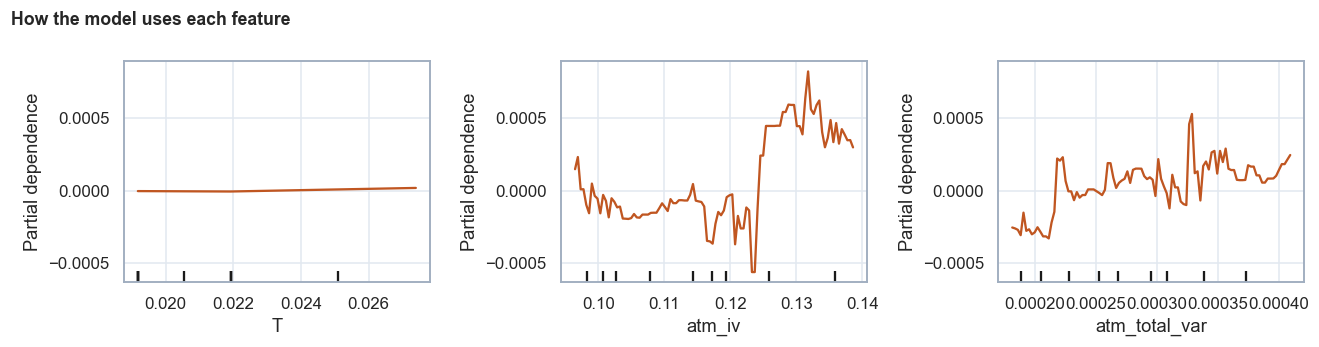

In [30]:
from sklearn.ensemble import HistGradientBoostingRegressor
from rvlab.plotting import pdp_grid

features = df[["T", "atm_iv", "atm_total_var"]]
model = HistGradientBoostingRegressor(max_iter=80, random_state=SEED).fit(features, y)
pdp_grid(model, features, ["T", "atm_iv", "atm_total_var"],
         title="How the model uses each feature");

## R7.28 · Check the palette in greyscale
<a id="r7-28"></a>

**Topic** Craft

**Use when** before any figure goes into a document. Print, photocopy and many screens destroy colour distinctions your monitor shows clearly.

**Inputs** `df`, or the arrays named in the call.

**Needs** nothing beyond the setup and data cells

**Gotchas** if two series collapse to the same grey, they are indistinguishable to a large number of readers — and you cannot tell by looking at the colour version.

**See also** [R7.29](#r7-29) (colour vision) · [R7.31](#r7-31) (export)

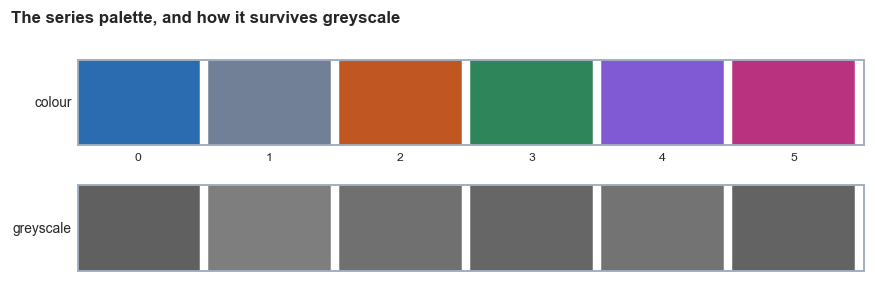

In [31]:
from rvlab.plotting import palette_preview

palette_preview(title="The series palette, and how it survives greyscale");

## R7.29 · Simulate colour blindness
<a id="r7-29"></a>

**Topic** Craft

**Use when** any figure distinguishing series by colour. Roughly 8% of men have reduced red-green vision — precisely the axis most default palettes rely on.

**Inputs** `df`, or the arrays named in the call.

**Needs** nothing beyond the setup and data cells

**Gotchas** the fix is rarely a different palette: it is a second visual channel. Vary line style, marker shape or direct labelling as well as hue, and the figure works for everyone.

**See also** [R7.28](#r7-28) (greyscale) · [R7.30](#r7-30) (labelling)

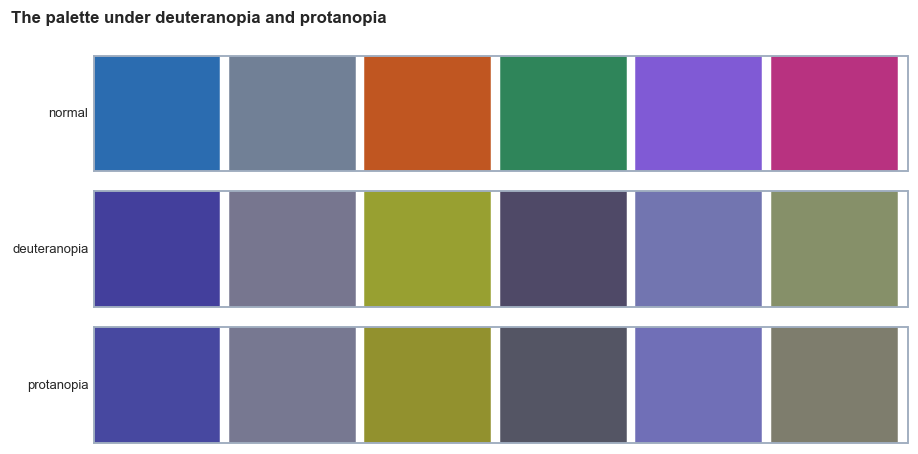

In [32]:
from rvlab.plotting import colorblind_check

colorblind_check(title="The palette under deuteranopia and protanopia");

## R7.30 · Annotate the finding
<a id="r7-30"></a>

**Topic** Craft

**Use when** every figure that will be read by someone other than you. One arrow and six words is usually the difference between a figure that communicates and one that merely displays.

**Inputs** `df`, or the arrays named in the call.

**Needs** nothing beyond the setup and data cells

**Gotchas** annotate the *conclusion*, not the mechanic. And offset in **points**, not data units — a data-unit offset is a `TypeError` on a datetime axis and needs re-tuning every time the range changes.

**See also** [R7.29](#r7-29) (a second channel) · [R7.31](#r7-31) (export)

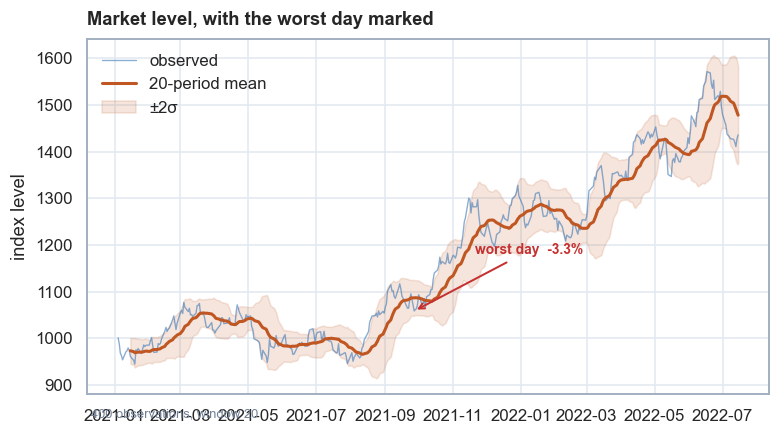

In [33]:
from rvlab.plotting import annotate_point, rolling_band

fig, ax = rolling_band(market, window=20, ylabel="index level",
                       title="Market level, with the worst day marked")
worst = returns.idxmin()
annotate_point(ax, worst, market.loc[worst], f"worst day  {returns.min():.1%}",
               dx=40, dy=35);

## R7.31 · Export at publication quality
<a id="r7-31"></a>

**Topic** Craft

**Use when** the figure is going into a document, a slide or a PDF.

**Inputs** `df`, or the arrays named in the call.

**Needs** nothing beyond the setup and data cells

**Gotchas** 300 dpi for raster; PDF when the figure will be scaled, because a vector survives being enlarged in a deck and a 150-dpi PNG does not. `bbox_inches="tight"` is set globally in the house style, so captions are never clipped.

**See also** [R7.30](#r7-30) (annotation) · [R4.21](when_a_result_is_real.ipynb#r4-21) (reporting)

  wrote gallery_example.png  (134 KB)
  wrote gallery_example.pdf  (23 KB)


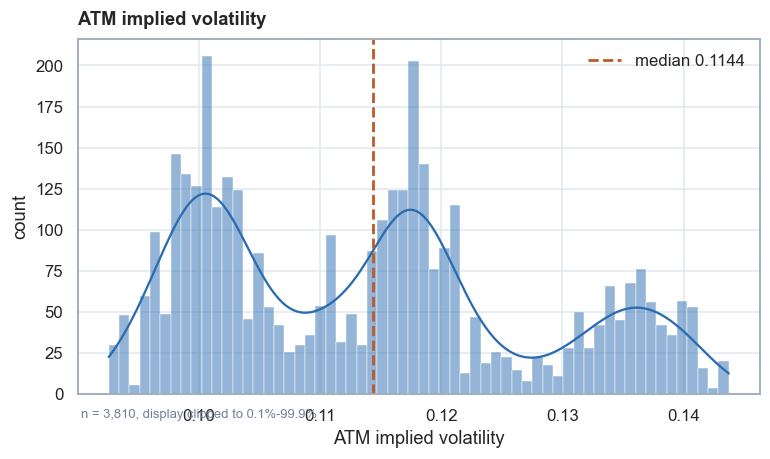

In [34]:
from rvlab.plotting import hist_kde, save_publication

fig, _ = hist_kde(df["atm_iv"], xlabel="ATM implied volatility",
                  title="ATM implied volatility")
for path in save_publication(fig, "gallery_example", dpi=300, formats=("png", "pdf")):
    print(f"  wrote {path.name}  ({path.stat().st_size / 1024:.0f} KB)")

## Combining sources without corrupting them

Joins and reshaping, run as a contract: state the row count you expect, then check it. Every failure below produces a frame that looks fine.

Its data cell binds `comp`, `crsp`, `join_detail`, `join_master`, `links`, `panel`, `smile`.

In [35]:
import warnings
import numpy as np, pandas as pd
from rvlab.data import load_chain_panel, load_smile_panel

smile = load_smile_panel(SMILE_DATASET)
panel = load_chain_panel()
panel["ts"] = pd.to_datetime(panel["timestamp_utc"], utc=True)
panel["expiry"] = pd.to_datetime(panel["expiry_date"]).dt.date

import tidyfinance as tf
pseudo_args = {"domain": "Pseudo Data", "start_date": PSEUDO_START,
               "end_date": PSEUDO_END}
with warnings.catch_warnings(record=True) as pseudo_warnings:
    warnings.simplefilter("always")
    crsp = tf.download_data(dataset="crsp_monthly", **pseudo_args)
    links = tf.download_data(dataset="ccm_links", **pseudo_args)
    comp = tf.download_data(dataset="compustat_annual", **pseudo_args)
pseudo_notice = 'Returning pseudo data from domain="Pseudo Data"'
if len(pseudo_warnings) != 3 or any(pseudo_notice not in str(item.message) for item in pseudo_warnings):
    raise RuntimeError(f"unexpected tidyfinance warnings: {[str(item.message) for item in pseudo_warnings]}")
print("NOTICE: tidyfinance supplied three schema-faithful simulated tables; they are not inference data.")

fixture_ts = pd.to_datetime(["2025-01-02 14:30Z", "2025-01-03 14:30Z"])
join_master = pd.DataFrame({"ts": fixture_ts, "underlying_price": [100.0, 101.0]})
join_detail = pd.DataFrame({"ts": fixture_ts.repeat(2),
                            "expiry": ["near", "far"] * 2,
                            "atm_iv": [0.20, 0.23, 0.21, 0.24]})
print(f"smile {smile.shape} · panel {panel.shape} · crsp {crsp.shape} · links {links.shape}")

NOTICE: tidyfinance supplied three schema-faithful simulated tables; they are not inference data.
smile (3810, 9) · panel (2029, 28) · crsp (13000, 14) · links (1000, 4)


## R7.32 · Diagnose a join before you run it
<a id="r7-32"></a>

**Topic** Joins

**Use when** always, on any join you have not run before. Key overlap, dtype agreement, duplicate keys on each side, and the predicted output size — all without touching the data.

**Inputs** two frames and a key.

**Needs** nothing beyond the setup and data cells

**Gotchas** the row to read is `predicted_rows`. If it exceeds the left frame's length the join will fan out, and you almost certainly meant to aggregate one side first ([R7.39](#r7-39)).

**See also** [R7.33](#r7-33) (the explosion) · [R7.34](#r7-34) (the dtype trap)

In [36]:
from rvlab.features import merge_report

report = merge_report(join_master, join_detail, on="ts", how="left")
assert report.attrs["summary"]["fans_out"]
report

,key,in_left,in_right,left_dtype,right_dtype,dtype_match,left_unique,right_unique,shared,left_only,right_only
0,ts,True,True,"datetime64[ns, UTC]","datetime64[ns, UTC]",True,2,2,2,0,0


The summary is the verdict. The deterministic fixture has one master row and two expiries per timestamp, so joining on `ts` alone must double the master. The assertion makes the example fail loudly if it ever stops demonstrating fan-out.

In [37]:
report.attrs["summary"].to_frame("value")

,value
how,left
left_rows,2
right_rows,4
duplicate_keys_left,0
duplicate_keys_right,2
predicted_rows,4
fans_out,True
dtype_mismatch,False


## R7.33 · Refuse a join that changes the row count unexpectedly
<a id="r7-33"></a>

**Topic** Joins

**Use when** every enrichment join. `safe_merge` states the contract — same row count, or fewer, or a fan-out you explicitly asked for — and raises when the data disagrees.

**Inputs** two frames, a key, and an `expect` contract.

**Needs** nothing beyond the setup and data cells

**Gotchas** use `validate=` as well as `expect=`. They catch different things: `validate` fires on the duplicated key, `expect` on the row-count consequence. A join that passes both is one you understand.

**See also** [R7.32](#r7-32) (predicting it) · [R7.39](#r7-39) (the fix)

In [38]:
from rvlab.features import safe_merge

try:
    safe_merge(join_master, join_detail, on="ts", how="left",
               validate="1:m", expect="same")
except ValueError as exc:
    print(f"refused: {exc}")
else:
    raise AssertionError("fan-out fixture did not raise")

refused: merge changed row count 2 -> 4; pass expect='any' if that is intended


Joining the option sources on the **composite** key enforces a 1:1 contract and preserves the left row count. The printed match rate answers a separate question: whether the sources actually cover the same observations. Cardinality safety does not imply temporal overlap.

In [39]:
joined = safe_merge(smile, panel[["ts", "expiry", "atm_iv"]].rename(
                        columns={"atm_iv": "atm_iv_panel"}),
                    on=["ts", "expiry"], how="left", validate="1:1")
print(f"{len(smile):,} -> {len(joined):,} rows, "
      f"{joined['atm_iv_panel'].notna().mean():.1%} matched")

3,810 -> 3,810 rows, 10.0% matched


## R7.34 · Find the dtype trap that returns an empty frame
<a id="r7-34"></a>

**Topic** Joins

**Use when** a join that should match returns nothing, or almost nothing. The cause is nearly always a key whose dtype differs between the two frames.

**Inputs** two frames sharing a key name.

**Needs** nothing beyond the setup and data cells

**Gotchas** the two that bite in this repository: a tz-aware `datetime64[ns, UTC]` against a **string** with a `+00:00` offset, and a `datetime.date` object against a `str`. Both look identical when printed. Neither matches.

**See also** [R7.32](#r7-32) (the report catches it) · [R1.10](the_volatility_surface.ipynb#r1-10) (timezones)

In [40]:
from rvlab.features import merge_report

raw_panel = load_chain_panel()          # timestamp_utc left as loaded
mismatched = merge_report(smile.assign(key=smile["ts"]),
                          raw_panel.assign(key=raw_panel["timestamp_utc"].astype(str)),
                          on="key")
mismatched[["key", "left_dtype", "right_dtype", "dtype_match", "shared"]]

,key,left_dtype,right_dtype,dtype_match,shared
0,key,"datetime64[ns, UTC]",object,False,0


The first report deliberately compares datetimes with their string representation, so it has zero shared keys. Converting both sides explicitly removes that representation error; the second report then reveals how much genuine timestamp overlap the selected sources contain. Put conversion at the loading boundary, and never confuse a dtype fix with a successful reconciliation.

In [41]:
fixed = merge_report(smile.assign(key=pd.to_datetime(smile["ts"], utc=True)),
                     raw_panel.assign(key=pd.to_datetime(raw_panel["timestamp_utc"], utc=True)),
                     on="key")
print(f"before conversion: {mismatched.iloc[0]['shared']:,} shared keys")
print(f"after conversion : {fixed.iloc[0]['shared']:,} shared keys")

before conversion: 0 shared keys
after conversion : 1,905 shared keys


## R7.35 · Compare two sources that measure the same thing
<a id="r7-35"></a>

**Topic** Cross-source joins

**Use when** you have two pipelines producing the same quantity. Join them and difference; when no composite keys overlap, report the comparison as unavailable instead of manufacturing a number.

**Inputs** the joined frame from [R7.33](#r7-33).

**Needs** R7.33 — run those first. This recipe builds on what they define.

**Gotchas** an inner join is right here, but an empty inner join is evidence too: the sources are not comparable on the requested keys. A left join would mix coverage with disagreement and can make the latter look smaller than it is.

**See also** [R6.23](where_the_numbers_come_from.ipynb#r6-23) (the same reconciliation) · [R7.33](#r7-33) (the join)

In [42]:
both = smile.merge(panel[["ts", "expiry", "atm_iv", "rr25_iv", "bf25_iv", "time_to_expiry"]],
                   on=["ts", "expiry"], how="inner", suffixes=("", "_panel"))
coverage = len(both) / max(len(smile), 1)
print(f"{len(both):,} rows measured by both pipelines ({coverage:.1%} of the left source)")
if both.empty:
    source_differences = pd.DataFrame(
        {"median_abs_diff": [np.nan] * 3, "status": ["not comparable: no shared composite keys"] * 3},
        index=["time_to_expiry", "atm_iv", "rr25"])
else:
    source_differences = pd.DataFrame({"median_abs_diff": [
        (both["T"] - both["time_to_expiry"]).abs().median(),
        (both["atm_iv"] - both["atm_iv_panel"]).abs().median(),
        (both["rr25"] - both["rr25_iv"]).abs().median()],
        "status": ["comparable"] * 3},
        index=["time_to_expiry", "atm_iv", "rr25"])
source_differences

381 rows measured by both pipelines (10.0% of the left source)


,median_abs_diff,status
time_to_expiry,2.6027e-07,comparable
atm_iv,1.5728e-04,comparable
rr25,2.1818e-03,comparable


## R7.36 · Establish that a join is impossible, in sixty seconds
<a id="r7-36"></a>

**Topic** Joins

**Use when** two files share a name and look joinable. Before writing any merge, check that a key actually exists, that the eras overlap, and that the values are mutually consistent.

**Inputs** two candidate frames.

**Needs** nothing beyond the setup and data cells

**Gotchas** this is the most valuable recipe in the notebook, because the alternative is spending an afternoon forcing a join that cannot mean anything. `data/spot_AAPL.csv` and `data/options_AAPL.csv` are the worked example — same ticker, same folder, and no possible relationship.

**See also** [R7.32](#r7-32) (diagnosing) · [R6.11](where_the_numbers_come_from.ipynb#r6-11) (finding candidates)

In [43]:
from rvlab.config import REPO_ROOT

spot = pd.read_csv(REPO_ROOT / "data/spot_AAPL.csv", parse_dates=["timestamp"])
opts = pd.read_csv(REPO_ROOT / "data/options_AAPL.csv")
print("spot   :", list(spot.columns), f"{len(spot)} rows")
print("options:", list(opts.columns), f"{len(opts)} rows")
print(f"\nshared column names: {sorted(set(spot.columns) & set(opts.columns)) or 'NONE'}")

spot   : ['timestamp', 'underlying_price'] 124 rows
options: ['strike', 'maturity_years', 'is_call', 'market_price', 'expiry'] 73 rows

shared column names: NONE


No shared column, and no observation date on the options at all — only an *expiry*. Three checks settle it.

In [44]:
implied_asof = pd.to_datetime(opts["expiry"]).min() - pd.Timedelta(
    days=float(opts["maturity_years"].min()) * 365)
atm = opts.query("is_call").nsmallest(1, "strike")
implied_spot = float(atm["strike"].iloc[0] + atm["market_price"].iloc[0])

print(f"1. spot covers      {spot.timestamp.min():%Y-%m-%d} to {spot.timestamp.max():%Y-%m-%d}")
print(f"2. options imply    as-of ~{implied_asof:%Y-%m-%d}  -> eras do not overlap")
print(f"3. options imply    spot ~{implied_spot:.0f}, but spot ranges "
      f"{spot.underlying_price.min():.0f}-{spot.underlying_price.max():.0f}")
print("\nVerdict: no join exists. Re-source one side rather than inventing a key.")

1. spot covers      2024-01-02 to 2024-06-28
2. options imply    as-of ~2026-03-12  -> eras do not overlap
3. options imply    spot ~262, but spot ranges 164-215

Verdict: no join exists. Re-source one side rather than inventing a key.


## R7.37 · Match each row to the most recent prior observation
<a id="r7-37"></a>

**Topic** As-of joins

**Use when** two series on different clocks — a minute-level panel against a daily series, a trade against the prevailing quote. `merge_asof` matches backwards in time.

**Inputs** two frames sorted by their time key. This worked example uses an aligned deterministic clock fixture so the direction contrast remains visible under every data mode.

**Needs** nothing beyond the setup and data cells

**Gotchas** > ⚠️ **Look-ahead:** `direction` must stay `"backward"` for anything predictive. `"forward"` and `"nearest"` will match a row to data recorded after it — a leak that improves your validation score with nothing to indicate it. And always set `tolerance`, or a gap in the right frame carries a stale value forward indefinitely.

**See also** [R7.38](#r7-38) (interval joins) · [R1.21](the_volatility_surface.ipynb#r1-21) (the simple case)

In [45]:
from rvlab.features import asof_join

clock = pd.date_range("2025-01-06", periods=4, freq="D", tz="UTC")
daily = pd.DataFrame({"date_key": clock,
                      "daily_realized_vol": [0.18, 0.22, 0.19, 0.24]})
intraday = pd.DataFrame({"date_key": clock[:-1] + pd.Timedelta(hours=12),
                         "trade_id": ["A", "B", "C"]})

matched = asof_join(intraday, daily[["date_key", "daily_realized_vol"]], on="date_key",
                    tolerance=pd.Timedelta(days=1))
print(matched.attrs["asof"])
matched.head(3)

{'direction': 'backward', 'tolerance': '1 days 00:00:00', 'match_rate': 1.0, 'sorted_on': ['date_key']}


,date_key,trade_id,daily_realized_vol
0,2025-01-06 12:00:00+00:00,A,0.18
1,2025-01-07 12:00:00+00:00,B,0.22
2,2025-01-08 12:00:00+00:00,C,0.19


Now the same join reaching the wrong way, so the failure is visible rather than theoretical.

In [46]:
forward = asof_join(intraday, daily[["date_key", "daily_realized_vol"]], on="date_key",
                    direction="forward", tolerance=pd.Timedelta(days=1))
comparable = matched["daily_realized_vol"].notna() & forward["daily_realized_vol"].notna()
changed = (matched.loc[comparable, "daily_realized_vol"] !=
           forward.loc[comparable, "daily_realized_vol"])
rate = changed.mean() if len(changed) else np.nan
print(f"{comparable.sum()} rows comparable in both directions; values differ on {rate:.1%}.")
assert comparable.any() and changed.any(), "fixture must expose forward-looking matches"

3 rows comparable in both directions; values differ on 100.0%.


## R7.38 · Join through a date-ranged link table
<a id="r7-38"></a>

**Topic** Interval joins

**Use when** the mapping between two identifiers is only valid between two dates. Security reclassifications, customer segments, CRSP-to-Compustat links — all have this shape.

**Inputs** an observation frame, a link table with start/end columns, and a shared id.

**Needs** nothing beyond the setup and data cells

**Gotchas** joining on the id alone attaches **every historical mapping to every row**. And a missing end date means 'still valid', not 'invalid' — `end_na_is_open=True` — so forgetting it silently drops every current mapping.

**See also** [R7.37](#r7-37) (as-of) · [R7.33](#r7-33) (catching the fan-out)

In [47]:
rng = np.random.default_rng(0)
split_ids = rng.choice(links["permno"].unique(), size=FRAGMENT_IDS, replace=False)
cut = pd.Timestamp(LINK_CUT)

before = links[links["permno"].isin(split_ids)].assign(linkenddt=cut - pd.Timedelta(days=1))
after = links[links["permno"].isin(split_ids)].assign(
    linkdt=cut, gvkey=lambda d: d["gvkey"].str.replace("^0", "9", regex=True))
fragmented = pd.concat([links[~links["permno"].isin(split_ids)], before, after],
                       ignore_index=True)
print(f"link table {len(links):,} -> {len(fragmented):,} rows "
      f"({FRAGMENT_IDS} ids now change mapping mid-sample)")

link table 1,000 -> 1,300 rows (300 ids now change mapping mid-sample)


The shipped pseudo table gives every id one permanent link, so it is fragmented here to create the situation real link tables always have. Now compare the naive join against the interval join.

In [48]:
from rvlab.features import interval_join

naive = crsp.merge(fragmented, on="permno", how="left")
correct = interval_join(crsp, fragmented, on="permno", left_time="date",
                        start="linkdt", end="linkenddt")

print(f"naive id-join : {len(naive):,} rows  ({len(naive) / len(crsp):.2f}x the input)")
print(f"interval join : {len(correct):,} rows  (1.00x)")
print(f"rows the naive join invented: {len(naive) - len(correct):,}")
print(f"duplicate (permno, date) after the interval join: "
      f"{correct.duplicated(['permno', 'date']).sum()}")

naive id-join : 16,900 rows  (1.30x the input)
interval join : 13,000 rows  (1.00x)
rows the naive join invented: 3,900
duplicate (permno, date) after the interval join: 0


## R7.39 · Aggregate first, then join
<a id="r7-39"></a>

**Topic** Joins

**Use when** the right frame has many rows per key and you want a summary, not a cross product. This is the fix for almost every fan-out.

**Inputs** a left frame, a detail frame, and the aggregations you want.

**Needs** nothing beyond the setup and data cells

**Gotchas** doing both steps in one call keeps them together, so the `validate="m:1"` is true by construction. The alternative — aggregate in one cell, merge three cells later — is how the aggregation quietly stops matching the join key.

**See also** [R7.33](#r7-33) (the explosion) · [R5.12](the_cross_section.ipynb#r5-12) (transform instead)

In [49]:
from rvlab.features import aggregate_and_join

per_ts = smile.groupby("ts", as_index=False)["atm_iv"].mean().rename(
    columns={"atm_iv": "_placeholder"})[["ts"]]
enriched = aggregate_and_join(per_ts, smile, "ts",
                              {"atm_iv": ["mean", "std"], "T": "max"}, prefix="smile_")
print(f"{len(per_ts):,} timestamps enriched, still {len(enriched):,} rows")
enriched.head(3)

1,905 timestamps enriched, still 1,905 rows


,ts,smile_atm_iv_mean,smile_atm_iv_std,smile_T_max
0,2025-08-07 13:35:00+00:00,0.1262,0.0022,0.0219
1,2025-08-07 13:36:00+00:00,0.1261,0.0022,0.0219
2,2025-08-07 13:37:00+00:00,0.1257,0.0022,0.0219


The alternative when you want the summary *broadcast back* onto every original row rather than collapsed: `groupby().transform()`, which preserves length by construction and cannot fan out.

In [50]:
broadcast = smile.assign(ts_mean_iv=smile.groupby("ts")["atm_iv"].transform("mean"))
print(f"aggregate_and_join -> {len(enriched):,} rows (one per key)")
print(f"groupby.transform  -> {len(broadcast):,} rows (one per original row)")

aggregate_and_join -> 1,905 rows (one per key)
groupby.transform  -> 3,810 rows (one per original row)


## R7.40 · Reconcile row counts across a chain of merges
<a id="r7-40"></a>

**Topic** Joins

**Use when** any pipeline with more than one join. Row counts drift a few at a time and nobody notices until the totals are wrong.

**Inputs** the frames before and after each step.

**Needs** R7.33, R7.38 — run those first. This recipe builds on what they define.

**Gotchas** `keys_lost` is the column that matters more than `row_delta`. Losing rows may be intentional; losing whole *entities* rarely is, and a left join cannot lose rows so it hides the problem entirely.

**See also** [R7.33](#r7-33) (per-join contracts) · [R6.10](where_the_numbers_come_from.ipynb#r6-10) (duplication)

In [51]:
from rvlab.features import reconcile

steps = [reconcile(smile, joined, "1. join panel on (ts, expiry)", key="expiry"),
         reconcile(joined, joined.dropna(subset=["atm_iv_panel"]), "2. drop unmatched",
                   key="expiry"),
         reconcile(crsp, correct, "3. crsp -> interval-linked", key="permno")]
pd.DataFrame(steps)

,step,rows_before,rows_after,row_delta,keys_before,keys_after,keys_lost
0,"1. join panel on (ts, expiry)",3810,3810,0,6,6,0
1,2. drop unmatched,3810,381,-3429,6,1,5
2,3. crsp -> interval-linked,13000,13000,0,1000,1000,0


## R7.41 · Melt a frame whose columns are dates
<a id="r7-41"></a>

**Topic** Reshaping

**Use when** the single most common untidy shape in delivered data: one column per period. Every time operation is impossible until it is fixed.

**Inputs** a frame with date-like column names.

**Needs** nothing beyond the setup and data cells

**Gotchas** detect the date columns by pattern rather than listing them, or the code breaks the moment a new period arrives. And convert the melted column to a real datetime — it arrives as a string.

**See also** [R7.42](#r7-42) (the reverse) · [R7.43](#r7-43) (stacking files)

In [52]:
from rvlab.features import dates_in_columns_to_long

wide = pd.DataFrame({
    "ticker": ["AAPL", "MSFT", "NVDA"], "model": ["Heston"] * 3,
    "2026-04-07": [1.637, 1.201, 0.884], "2026-04-08": [2.000, 1.150, 0.910]})
print("as delivered — dates are column names:")
display(wide)

as delivered — dates are column names:


,ticker,model,2026-04-07,2026-04-08
0,AAPL,Heston,1.637,2.00
1,MSFT,Heston,1.201,1.15
2,NVDA,Heston,0.884,0.91


One call, and every subsequent operation becomes possible.

In [53]:
tidy = dates_in_columns_to_long(wide, id_vars=["ticker", "model"],
                                var_name="date", value_name="xi")
print(f"{wide.shape} -> {tidy.shape}, date dtype {tidy['date'].dtype}")
tidy

(3, 4) -> (6, 4), date dtype datetime64[ns]


,ticker,model,date,xi
0,AAPL,Heston,2026-04-07,1.637
1,AAPL,Heston,2026-04-08,2.000
2,MSFT,Heston,2026-04-07,1.201
3,MSFT,Heston,2026-04-08,1.150
4,NVDA,Heston,2026-04-07,0.884
5,NVDA,Heston,2026-04-08,0.910


## R7.42 · Pivot long back to wide, safely
<a id="r7-42"></a>

**Topic** Reshaping

**Use when** you need a matrix — one row per entity, one column per period — for a heatmap, a correlation, or a model that expects it.

**Inputs** a long frame with index, column and value fields.

**Needs** R7.41 — run those first. This recipe builds on what they define.

**Gotchas** use `pivot_table`, not `pivot`. `pivot` raises on duplicate index/column pairs, and real data has them; `pivot_table` forces you to pass an `aggfunc` and therefore to *decide* what a duplicate means, instead of discovering it as an exception.

**See also** [R7.41](#r7-41) (the forward direction) · [R7.44](#r7-44) (flattening the result)

In [54]:
from rvlab.features import long_to_wide

matrix = long_to_wide(tidy, index="ticker", columns="date", values="xi")
matrix

,ticker,2026-04-07 00:00:00,2026-04-08 00:00:00
0,AAPL,1.637,2.00
1,MSFT,1.201,1.15
2,NVDA,0.884,0.91


The duplicate case, where `pivot` would raise and `pivot_table` asks you what you meant.

In [55]:
dupes = pd.concat([tidy, tidy.head(1).assign(xi=9.9)], ignore_index=True)
try:
    dupes.pivot(index="ticker", columns="date", values="xi")
except ValueError as exc:
    print(f"pivot raises: {str(exc)[:70]}...")
print("\npivot_table with aggfunc='mean' resolves it:")
display(long_to_wide(dupes, "ticker", "date", "xi", aggfunc="mean"))

pivot raises: Index contains duplicate entries, cannot reshape...



pivot_table with aggfunc='mean' resolves it:


,ticker,2026-04-07 00:00:00,2026-04-08 00:00:00
0,AAPL,5.7685,2.00
1,MSFT,1.2010,1.15
2,NVDA,0.8840,0.91


## R7.43 · Stack many files into one frame with a label column
<a id="r7-43"></a>

**Topic** Reshaping

**Use when** several files share a schema and differ only in which variant produced them. Concatenate with a label, and the comparison becomes a groupby.

**Inputs** a set of same-schema files.

**Needs** nothing beyond the setup and data cells

**Gotchas** add the label **while reading**, not afterwards. Once the frames are concatenated the provenance is gone, and reconstructing it from row order is how the wrong label ends up on the wrong rows.

**See also** [R6.9](where_the_numbers_come_from.ipynb#r6-9) (path metadata) · [R8.15](measuring_and_trading_volatility.ipynb#r8-15) (using this)

In [56]:
from rvlab.config import REPO_ROOT

paths = sorted((REPO_ROOT / "demo/build/results").glob("oos_*.csv"))
if paths:
    stacked = pd.concat([pd.read_csv(p).assign(strategy=p.stem.replace("oos_", ""))
                         for p in paths], ignore_index=True)
    print(f"{len(paths)} files -> {stacked.shape}, "
          f"{stacked['strategy'].nunique()} strategies")
    display(stacked.groupby("strategy")["total_pnl"].agg(["count", "sum"]).round(2))
else:
    print("demo/build/results not present on this machine")

5 files -> (125, 13), 5 strategies


,count,sum
strategy,,
bs_delta,25,1.0600e+06
bsde_is_delta,25,8.8595e+05
bsde_is_full,25,2.8485e+05
bsde_synth,25,1.0600e+06
rough_delta,25,7.0020e+05


## R7.44 · Handle the MultiIndex a groupby hands you
<a id="r7-44"></a>

**Topic** Reshaping

**Use when** any `groupby().agg()` with several statistics returns MultiIndex columns, and most downstream tools are happier without them.

**Inputs** an aggregated frame.

**Needs** nothing beyond the setup and data cells

**Gotchas** flatten early. `ColumnTransformer`, `to_csv` and most plotting either fail or produce unreadable labels on a MultiIndex, and the failure often appears several steps later.

**See also** [R7.42](#r7-42) (pivot output) · [R7.39](#r7-39) (aggregation)

In [57]:
from rvlab.features import flatten_multiindex

agg = smile.groupby("expiry").agg({"atm_iv": ["mean", "std"], "rr25": "mean"})
print("MultiIndex columns:", list(agg.columns)[:3])
flat = flatten_multiindex(agg).reset_index()
print("flattened          :", list(flat.columns))
flat.head(3)

MultiIndex columns: [('atm_iv', 'mean'), ('atm_iv', 'std'), ('rr25', 'mean')]
flattened          : ['expiry', 'atm_iv_mean', 'atm_iv_std', 'rr25_mean']


,expiry,atm_iv_mean,atm_iv_std,rr25_mean
0,2025-08-14,0.1342,0.0039,-0.0348
1,2025-08-15,0.1281,0.0094,-0.0337
2,2025-08-18,0.1137,0.0049,-0.0290


For a genuine MultiIndex *index*, `xs` selects a level and `swaplevel` reorders one — both far cheaper than resetting and re-grouping.

In [58]:
nested = smile.set_index(["expiry", "ts"]).sort_index()
one_expiry = nested.xs(nested.index.get_level_values(0)[0], level="expiry")
print(f"xs on one expiry -> {len(one_expiry):,} rows, index is now {one_expiry.index.name}")
print("swaplevel ->", nested.swaplevel().index.names)

xs on one expiry -> 381 rows, index is now ts
swaplevel -> ['ts', 'expiry']


## Verdict & what carries forward

Both halves reduce to the same discipline — decide what the output should be before producing it, then check that it is.

### Evidence you can see

Thirty-one charts, each with the situation it is for. The choices that recur:

* **Form before colour.** ECDF past two groups, hexbin past five thousand points, facets past
  seven series. Almost every unreadable figure is a form problem, not a palette problem.
* **Plot the uncertainty.** A bar without an error bar asserts a difference; an event study
  without a band invents one; a violin without its points implies a density three observations
  cannot support.
* **Never use a twin y-axis to compare series.** Two independently-scaled axes can be slid
  until anything appears to co-move, and the reader cannot detect it. Rebase instead
  ([R7.17](#r7-17)).
* **Check greyscale and colour vision** ([R7.28](#r7-28), [R7.29](#r7-29)). The fix is
  usually a second visual channel rather than a different palette.
* **Say what you found in the title**, and put an arrow on it. A figure that requires the
  reader to locate the finding usually fails to deliver it.

Next in this notebook: **Combining sources without corrupting them**.

### Combining sources without corrupting them

Joins done deliberately rather than hopefully. What carries forward:

* **`ts` alone was never the key.** [R7.33](#r7-33) refuses a deterministic fixture
  with two detail rows per timestamp. The composite `(ts, expiry)` enforces 1:1 cardinality;
  its match rate separately reports whether the selected sources overlap.
* **A dtype mismatch produced zero shared keys** ([R7.34](#r7-34)). Explicit conversion
  fixes representation, while the post-conversion overlap reveals whether the eras align.
* **The naive link-table join invented rows**, silently, because a date-ranged mapping
  was treated as a permanent one; [R7.38](#r7-38) prints the realized multiplier.
* **Some joins do not exist.** `spot_AAPL` and `options_AAPL` share a ticker, a folder and
  nothing else: no observation date, non-overlapping eras, and an implied spot outside the
  other file's entire range. Establishing that took three lines ([R7.36](#r7-36)) and saved
  an afternoon.

The habit underneath all of them: **state the expected row count, then check it.** Every
recipe here is a variation on that.

**Sixty-second merge checklist**

1. Normalize key dtypes and measure actual key overlap.
2. State `1:1`, `m:1` or intentional `1:m` cardinality before calling `merge`.
3. Record rows and unique keys before and after; inspect unmatched rows.
4. For time joins, use the latest record available at or before the observation plus a
   defensible staleness tolerance.
5. Stop when the sources have no defensible shared key; do not manufacture one.

Next: [Measuring Volatility, and Trading It](measuring_and_trading_volatility.ipynb).